In [1]:
import sys
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib as matplotlib
import scipy as scipy

import subprocess
import os
import scipy.stats as stats
from collections import Counter

import seaborn as sns

plt.rcParams["font.sans-serif"]='Arial'

In [2]:
np.__version__, matplotlib.__version__, scipy.__version__,  pd.__version__, sns.__version__

('1.26.4', '3.9.2', '1.13.1', '2.2.2', '0.13.2')

In [3]:
print(sys.version)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:27:36) [GCC 11.2.0]


In [4]:
screen_1_counts = pd.read_csv('./sgRNAs_annot_wcounts_screen_1.csv', index_col=0)
screen_1_counts

,Gene,alias,SgRNA,Barcode,PAM,control,strand,atg_dist,B_mismatch,dist_TSS,...,WT_T2_NoATC_3,WT_T2_ATC_1,WT_T2_ATC_2,WT_T2_ATC_3,WT_T3_NoATC_1,WT_T3_NoATC_2,WT_T3_NoATC_3,WT_T3_ATC_1,WT_T3_ATC_2,WT_T3_ATC_3
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,TGG,0,+,112.0,no,-9.0,...,133.0,164.0,139.0,146.0,272.0,313.0,314.0,445.0,243.0,332.0
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,AGG,0,-,45.0,no,58.0,...,263.0,258.0,241.0,293.0,477.0,559.0,529.0,774.0,437.0,641.0
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,TGG,0,-,38.0,no,65.0,...,8.0,11.0,10.0,10.0,36.0,39.0,15.0,44.0,18.0,28.0
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,AGG,0,+,288.0,no,-185.0,...,101.0,120.0,101.0,128.0,282.0,239.0,208.0,319.0,223.0,255.0
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,AGG,0,-,177.0,no,-89.0,...,103.0,162.0,152.0,191.0,222.0,274.0,246.0,429.0,236.0,343.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,NaN,1,NaN,NaN,no,NaN,...,1096.0,1306.0,1121.0,1323.0,2477.0,2605.0,2602.0,3503.0,2042.0,2772.0
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,NaN,1,NaN,NaN,no,NaN,...,453.0,494.0,422.0,561.0,994.0,1003.0,1159.0,1370.0,791.0,1089.0
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,NaN,1,NaN,NaN,no,NaN,...,1879.0,2265.0,1891.0,2229.0,3908.0,4170.0,4003.0,5642.0,3523.0,4437.0
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,NaN,1,NaN,NaN,no,NaN,...,103.0,129.0,101.0,118.0,202.0,168.0,235.0,310.0,199.0,287.0


In [5]:
raw_count_col = ['WT_0_T0_T0', 'WT_T1_NoATC_1', 'WT_T1_NoATC_2', 'WT_T1_NoATC_3', 'WT_T1_ATC_1', 'WT_T1_ATC_2', 'WT_T1_ATC_3', 'WT_T2_NoATC_1', 'WT_T2_NoATC_2', 'WT_T2_NoATC_3', 'WT_T2_ATC_1', 'WT_T2_ATC_2', 'WT_T2_ATC_3', 'WT_T3_NoATC_1', 'WT_T3_NoATC_2', 'WT_T3_NoATC_3', 'WT_T3_ATC_1', 'WT_T3_ATC_2', 'WT_T3_ATC_3']

WT_0_T0_T0 21 41.1 60
WT_T1_NoATC_1
WT_T1_NoATC_2
WT_T1_NoATC_3
WT_T1_ATC_1
WT_T1_ATC_2
WT_T1_ATC_3


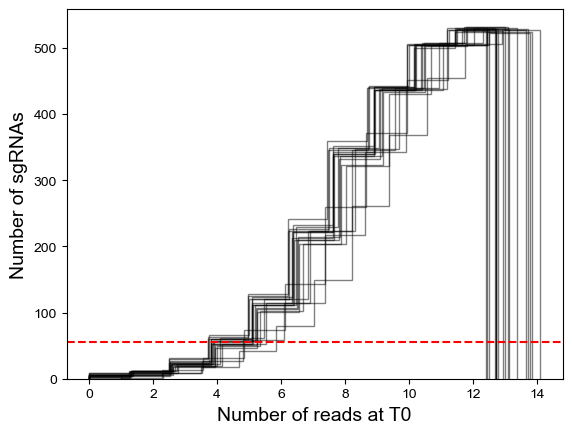

In [6]:
for col in raw_count_col: 
    if 'T0' in col:
        print(col, 553-len(screen_1_counts[col].dropna()), np.percentile(screen_1_counts[col].dropna(),10), 553-len(screen_1_counts[screen_1_counts[col]>=32]))
        
    if 'T1' in col:
        plt.hist(np.log2(screen_1_counts[col].dropna()), histtype='step', cumulative=True, color='k', alpha=0.5)
        print(col)

    elif 'T2' in col:
        plt.hist(np.log2(screen_1_counts[col].dropna()), histtype='step', cumulative=True, color='k', alpha=0.5)

    elif 'T3' in col:
        plt.hist(np.log2(screen_1_counts[col].dropna()), histtype='step', cumulative=True, color='k', alpha=0.5)
        
        
#plt.xticks([0,2,4,6,8,10,12,14], [str(2**x) for x in [0,2,4,6,8,10,12,14]])

plt.xlabel('Number of reads at T0', fontsize=14)
plt.ylabel('Number of sgRNAs', fontsize=14)


plt.axhline(55,color='r', linestyle='--')

In [7]:
screen_1_counts[screen_1_counts['control']<2]['WT_0_T0_T0']



0       176.0
1       362.0
2        15.0
3       160.0
4       212.0
        ...  
547     253.0
548    1851.0
549     707.0
550    2985.0
551     129.0
Name: WT_0_T0_T0, Length: 552, dtype: float64

In [8]:
sgRNA_above_initial_threshold_list = list(screen_1_counts[(screen_1_counts['control']==0) & (screen_1_counts['WT_0_T0_T0']>=50)]['alias'].value_counts())
len(sgRNA_above_initial_threshold_list)

130

In [9]:
468/552

0.8478260869565217

In [10]:
len([x for x in sgRNA_above_initial_threshold_list if x==0])

0

In [11]:
screen_1_counts[(screen_1_counts['control']<1) & (screen_1_counts['WT_0_T0_T0']>=50)]['WT_0_T0_T0']

0       176.0
1       362.0
3       160.0
4       212.0
5       682.0
        ...  
516     412.0
517     121.0
519     370.0
520      84.0
521    7236.0
Name: WT_0_T0_T0, Length: 438, dtype: float64

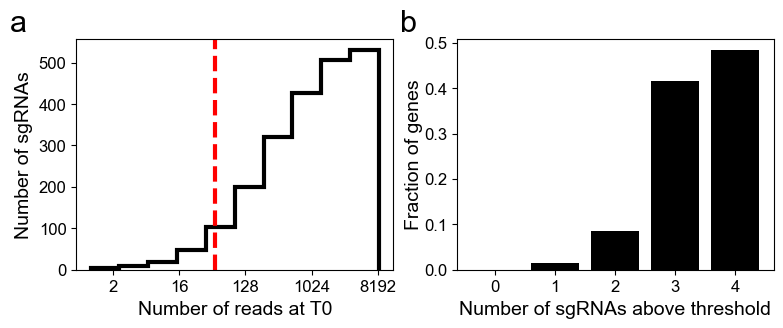

In [12]:
plt.figure(figsize=(9,3))

plt.subplot(121)
plt.hist(np.log2(screen_1_counts[screen_1_counts['control']<2]['WT_0_T0_T0']), histtype='step', cumulative=True, color='k', lw=3)
plt.axvline(np.log2(50), linestyle='--', color='red', lw=3)

plt.xlabel('Number of reads at T0', fontsize=14)
plt.xticks([1,4,7,10,13], [str(2**1), str(2**4), str(2**7), str(2**10), str(2**13)], fontsize=12)
plt.ylabel('Number of sgRNAs', fontsize=14)
plt.yticks(fontsize=12)

plt.text(-3.65, 575, 'a', fontsize=22)
plt.text(14, 575, 'b', fontsize=22)

plt.subplot(122)

plt.bar([0,1,2,3,4], [len([x for x in sgRNA_above_initial_threshold_list if x==0])/130,
                      len([x for x in sgRNA_above_initial_threshold_list if x==1])/130,
                      len([x for x in sgRNA_above_initial_threshold_list if x==2])/130,
                      len([x for x in sgRNA_above_initial_threshold_list if x==3])/130,
                      len([x for x in sgRNA_above_initial_threshold_list if x==4])/130], color='k')

plt.xlabel('Number of sgRNAs above threshold', fontsize=14)
plt.xticks(fontsize=12)

plt.ylabel('Fraction of genes', fontsize=14, labelpad=0.5)
plt.yticks(fontsize=12)

plt.savefig('./timecourse_screen_initial_abundance.svg', format='svg', dpi=300, bbox_inches='tight')


In [13]:
freq_col_list = []

for col in raw_count_col:
    freq_col = ('freq_'+col)
    screen_1_counts[('freq_'+col)] = ((screen_1_counts[col].fillna(value=0))+1)/(screen_1_counts[col].sum()+len(screen_1_counts))
    freq_col_list.append(freq_col)
    # now we do this for all read count columns in the dataset
screen_1_counts
# go from raw read count for each sgRNA to their relative abundance
# we add one to every count to avoid issues with 0 values when computing log2 fold change downstream
# to take this into account, we add 1*n_sgrna to the denominator so the total of fractions remains 1

,Gene,alias,SgRNA,Barcode,PAM,control,strand,atg_dist,B_mismatch,dist_TSS,...,freq_WT_T2_NoATC_3,freq_WT_T2_ATC_1,freq_WT_T2_ATC_2,freq_WT_T2_ATC_3,freq_WT_T3_NoATC_1,freq_WT_T3_NoATC_2,freq_WT_T3_NoATC_3,freq_WT_T3_ATC_1,freq_WT_T3_ATC_2,freq_WT_T3_ATC_3
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,TGG,0,+,112.0,no,-9.0,...,0.000488,0.000486,0.000472,0.000432,0.000480,0.000527,0.000515,0.000508,0.000451,0.000480
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,AGG,0,-,45.0,no,58.0,...,0.000961,0.000763,0.000817,0.000863,0.000841,0.000941,0.000867,0.000883,0.000809,0.000925
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,TGG,0,-,38.0,no,65.0,...,0.000033,0.000035,0.000037,0.000032,0.000065,0.000067,0.000026,0.000051,0.000035,0.000042
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,AGG,0,+,288.0,no,-185.0,...,0.000371,0.000356,0.000344,0.000379,0.000498,0.000403,0.000342,0.000364,0.000414,0.000369
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,AGG,0,-,177.0,no,-89.0,...,0.000379,0.000480,0.000516,0.000564,0.000392,0.000462,0.000404,0.000490,0.000438,0.000495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,NaN,1,NaN,NaN,no,NaN,...,0.003995,0.003848,0.003787,0.003887,0.004359,0.004377,0.004256,0.003991,0.003772,0.003994
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,NaN,1,NaN,NaN,no,NaN,...,0.001653,0.001458,0.001428,0.001650,0.001750,0.001686,0.001897,0.001561,0.001462,0.001570
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,NaN,1,NaN,NaN,no,NaN,...,0.006847,0.006672,0.006385,0.006547,0.006877,0.007006,0.006547,0.006427,0.006507,0.006392
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,NaN,1,NaN,NaN,no,NaN,...,0.000379,0.000383,0.000344,0.000349,0.000357,0.000284,0.000386,0.000354,0.000369,0.000415


Text(0, 0.5, 'Freq')

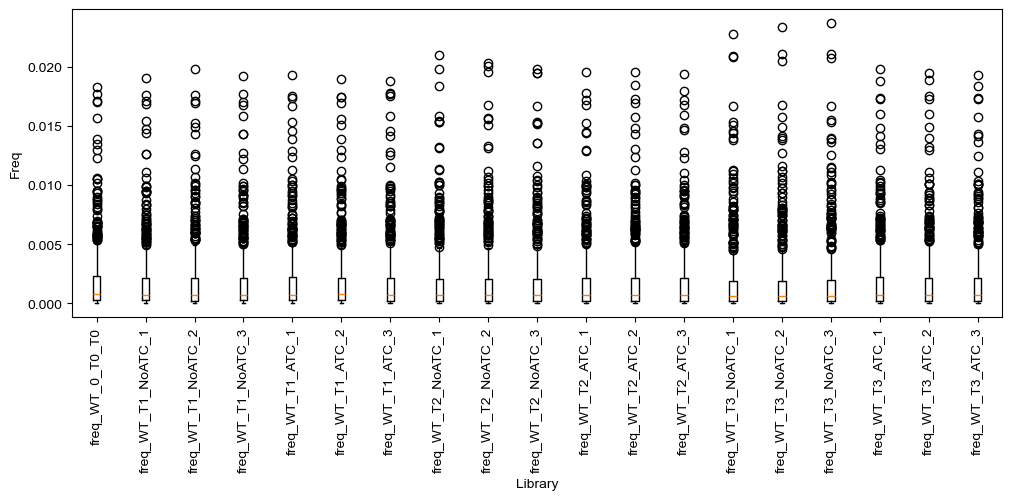

In [14]:
plt.figure(figsize=(12,4))

# let's also look at the distribution of raw abundances for each library

x=0

for col in freq_col_list:
    # print the number of reads for each library
    
    plt.boxplot(screen_1_counts[col].dropna(), positions=[x])
    x+=1
    


plt.xticks(range(0, len(freq_col_list)), freq_col_list, rotation=90)
# label x-ticks

plt.xlabel('Library')
plt.ylabel('Freq')
# format axis labels

In [15]:
timepoint_list = ['T1', 'T2', 'T3']

rep_list = ['1','2','3']


log2_col_list = []

count_col=0

for timepoint in timepoint_list:
    for rep in rep_list:
        ref_col = 'freq_WT_0_T0_T0' 
        count_col+=2

        strain_col_noATC = 'freq_WT_'+timepoint+'_NoATC_'+rep
        log2_col_name_noATC = 'log2fc_'+timepoint+'_NoATC_'+rep
        #print(ref_col_noATC,strain_col_noATC, log2_col_name_noATC)

        strain_col_ATC = 'freq_WT_'+timepoint+'_ATC_'+rep
        log2_col_name_ATC = 'log2fc_'+timepoint+'_ATC_'+rep
        #print(ref_col_ATC,strain_col_ATC, log2_col_name_ATC)

        log2_col_list.append(log2_col_name_noATC)
        log2_col_list.append(log2_col_name_ATC)

        screen_1_counts[log2_col_name_noATC] = np.log2(screen_1_counts[strain_col_noATC]) - np.log2(screen_1_counts[ref_col])
        screen_1_counts[log2_col_name_ATC] = np.log2(screen_1_counts[strain_col_ATC]) - np.log2(screen_1_counts[ref_col])
                
print(count_col)
screen_1_counts

18


,Gene,alias,SgRNA,Barcode,PAM,control,strand,atg_dist,B_mismatch,dist_TSS,...,log2fc_T2_NoATC_2,log2fc_T2_ATC_2,log2fc_T2_NoATC_3,log2fc_T2_ATC_3,log2fc_T3_NoATC_1,log2fc_T3_ATC_1,log2fc_T3_NoATC_2,log2fc_T3_ATC_2,log2fc_T3_NoATC_3,log2fc_T3_ATC_3
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,TGG,0,+,112.0,no,-9.0,...,0.540530,0.298504,0.345179,0.167845,0.322029,0.402936,0.457201,0.229778,0.423029,0.320125
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,AGG,0,-,45.0,no,58.0,...,0.290341,0.051864,0.287264,0.131625,0.093918,0.163868,0.255643,0.037608,0.137450,0.230956
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,TGG,0,-,38.0,no,65.0,...,0.177194,0.096258,-0.083380,-0.104790,0.906330,0.561494,0.952114,0.014574,-0.408573,0.266333
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,AGG,0,+,288.0,no,-185.0,...,-0.008673,-0.021665,0.088204,0.116088,0.510618,0.060653,0.206160,0.243085,-0.032131,0.077435
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,AGG,0,-,177.0,no,-89.0,...,0.018169,0.159505,-0.287575,0.286031,-0.236933,0.083125,-0.001236,-0.079320,-0.194916,0.099907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,NaN,1,NaN,NaN,no,NaN,...,-0.019463,-0.086185,-0.008825,-0.048403,0.116969,-0.010440,0.122939,-0.091748,0.082518,-0.009285
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,NaN,1,NaN,NaN,no,NaN,...,-0.019308,-0.106265,0.105638,0.102599,0.187824,0.023049,0.134124,-0.071602,0.303730,0.030859
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,NaN,1,NaN,NaN,no,NaN,...,0.022206,-0.021475,0.079214,0.014607,0.085462,-0.012110,0.112365,0.005646,0.014655,-0.019953
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,NaN,1,NaN,NaN,no,NaN,...,0.541849,0.286884,0.424767,0.308228,0.339845,0.328044,0.008698,0.388135,0.451702,0.555909


In [16]:
screen_1_counts.at[539, 'control'] = 2
# exclude sgRNA-R18 from test values due to its outlier status across multiple experiments and genetic backgrounds.

In [17]:
def set_to_nan(log2_fc, count, threshold):
    # Function to apply initial abundance filter to columns: will change values in log2fc for a sgRNA
    # to nan if the value in the count col is below or equal to threshold. Can be applied to a column
    # using a lambda function
    
    #print(log2_fc, count, threshold)
    # debugging print call
    
    if count <= threshold:
        return np.NaN
    elif np.isnan(count)==True:
        return np.NaN
    else:
        return log2_fc

In [18]:
np.log2(30)

4.906890595608519

In [19]:
timepoint_list = ['T1', 'T2', 'T3']

rep_list = ['1','2','3']


log2_col_list = []

count_col=0

for timepoint in timepoint_list:
    for rep in rep_list:
        ref_col = 'WT_0_T0_T0' 
           

        strain_col_noATC = 'freq_WT_'+timepoint+'_NoATC_'+rep
        log2_col_name_noATC = 'log2fc_'+timepoint+'_NoATC_'+rep
        #print(ref_col_noATC,strain_col_noATC, log2_col_name_noATC)

        strain_col_ATC = 'freq_WT_'+timepoint+'_ATC_'+rep
        log2_col_name_ATC = 'log2fc_'+timepoint+'_ATC_'+rep
        #print(ref_col_ATC,strain_col_ATC, log2_col_name_ATC)

        log2_col_list.append(log2_col_name_noATC)
        log2_col_list.append(log2_col_name_ATC)

        screen_1_counts[log2_col_name_noATC+'_filter'] = screen_1_counts.apply(lambda x: set_to_nan(x[log2_col_name_noATC], x[ref_col], 50),axis=1)
        print('dropped '+str(553-len(screen_1_counts[log2_col_name_noATC+'_filter'].dropna()))+' for column '+log2_col_name_noATC)
        #print((background+'_T0_YPD_'+rep))
        
        
        screen_1_counts[log2_col_name_ATC+'_filter'] = screen_1_counts.apply(lambda x: set_to_nan(x[log2_col_name_ATC], x[ref_col], 50),axis=1)
        print('dropped '+str(553-len(screen_1_counts[log2_col_name_ATC+'_filter'].dropna()))+' for column '+log2_col_name_ATC)
                
print(count_col)
screen_1_counts

dropped 84 for column log2fc_T1_NoATC_1
dropped 84 for column log2fc_T1_ATC_1
dropped 84 for column log2fc_T1_NoATC_2
dropped 84 for column log2fc_T1_ATC_2
dropped 84 for column log2fc_T1_NoATC_3
dropped 84 for column log2fc_T1_ATC_3
dropped 84 for column log2fc_T2_NoATC_1
dropped 84 for column log2fc_T2_ATC_1
dropped 84 for column log2fc_T2_NoATC_2
dropped 84 for column log2fc_T2_ATC_2
dropped 84 for column log2fc_T2_NoATC_3
dropped 84 for column log2fc_T2_ATC_3
dropped 84 for column log2fc_T3_NoATC_1
dropped 84 for column log2fc_T3_ATC_1
dropped 84 for column log2fc_T3_NoATC_2
dropped 84 for column log2fc_T3_ATC_2
dropped 84 for column log2fc_T3_NoATC_3
dropped 84 for column log2fc_T3_ATC_3
0


,Gene,alias,SgRNA,Barcode,PAM,control,strand,atg_dist,B_mismatch,dist_TSS,...,log2fc_T2_NoATC_2_filter,log2fc_T2_ATC_2_filter,log2fc_T2_NoATC_3_filter,log2fc_T2_ATC_3_filter,log2fc_T3_NoATC_1_filter,log2fc_T3_ATC_1_filter,log2fc_T3_NoATC_2_filter,log2fc_T3_ATC_2_filter,log2fc_T3_NoATC_3_filter,log2fc_T3_ATC_3_filter
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,TGG,0,+,112.0,no,-9.0,...,0.540530,0.298504,0.345179,0.167845,0.322029,0.402936,0.457201,0.229778,0.423029,0.320125
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,AGG,0,-,45.0,no,58.0,...,0.290341,0.051864,0.287264,0.131625,0.093918,0.163868,0.255643,0.037608,0.137450,0.230956
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,TGG,0,-,38.0,no,65.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,AGG,0,+,288.0,no,-185.0,...,-0.008673,-0.021665,0.088204,0.116088,0.510618,0.060653,0.206160,0.243085,-0.032131,0.077435
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,AGG,0,-,177.0,no,-89.0,...,0.018169,0.159505,-0.287575,0.286031,-0.236933,0.083125,-0.001236,-0.079320,-0.194916,0.099907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,NaN,1,NaN,NaN,no,NaN,...,-0.019463,-0.086185,-0.008825,-0.048403,0.116969,-0.010440,0.122939,-0.091748,0.082518,-0.009285
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,NaN,1,NaN,NaN,no,NaN,...,-0.019308,-0.106265,0.105638,0.102599,0.187824,0.023049,0.134124,-0.071602,0.303730,0.030859
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,NaN,1,NaN,NaN,no,NaN,...,0.022206,-0.021475,0.079214,0.014607,0.085462,-0.012110,0.112365,0.005646,0.014655,-0.019953
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,NaN,1,NaN,NaN,no,NaN,...,0.541849,0.286884,0.424767,0.308228,0.339845,0.328044,0.008698,0.388135,0.451702,0.555909


In [20]:
screen_1_counts['median_log2fc_NoATC_T1'] = screen_1_counts[['log2fc_T1_NoATC_1_filter', 'log2fc_T1_NoATC_2_filter', 'log2fc_T1_NoATC_3_filter']].median(skipna=False, axis=1)
screen_1_counts['median_log2fc_NoATC_T2'] = screen_1_counts[['log2fc_T2_NoATC_1_filter', 'log2fc_T2_NoATC_2_filter', 'log2fc_T2_NoATC_3_filter']].median(skipna=False, axis=1)
screen_1_counts['median_log2fc_NoATC_T3'] = screen_1_counts[['log2fc_T3_NoATC_1_filter', 'log2fc_T3_NoATC_2_filter', 'log2fc_T3_NoATC_3_filter']].median(skipna=False, axis=1)

In [21]:
screen_1_counts['median_log2fc_ATC_T1'] = screen_1_counts[['log2fc_T1_ATC_1_filter', 'log2fc_T1_ATC_2_filter', 'log2fc_T1_ATC_3_filter']].median(skipna=False, axis=1)
screen_1_counts['median_log2fc_ATC_T2'] = screen_1_counts[['log2fc_T2_ATC_1_filter', 'log2fc_T2_ATC_2_filter', 'log2fc_T2_ATC_3_filter']].median(skipna=False, axis=1)
screen_1_counts['median_log2fc_ATC_T3'] = screen_1_counts[['log2fc_T3_ATC_1_filter', 'log2fc_T3_ATC_2_filter', 'log2fc_T3_ATC_3_filter']].median(skipna=False, axis=1)

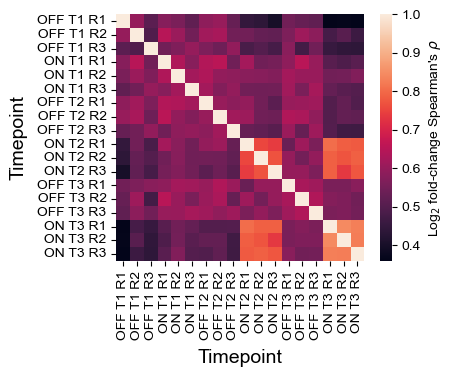

In [22]:
plt.figure(figsize=(4,3.2))

sns.heatmap(screen_1_counts[[ 'log2fc_T1_ATC_1_filter',  'log2fc_T1_ATC_2_filter', 'log2fc_T1_ATC_3_filter', 
                       'log2fc_T1_NoATC_1_filter', 'log2fc_T1_NoATC_2_filter', 'log2fc_T1_NoATC_3_filter',
                       'log2fc_T2_ATC_1_filter', 'log2fc_T2_ATC_2_filter', 'log2fc_T2_ATC_3_filter',
                       'log2fc_T2_NoATC_1_filter',  'log2fc_T2_NoATC_2_filter', 'log2fc_T2_NoATC_3_filter',
                       'log2fc_T3_ATC_1_filter', 'log2fc_T3_ATC_2_filter', 'log2fc_T3_ATC_3_filter',
                       'log2fc_T3_NoATC_1_filter',  'log2fc_T3_NoATC_2_filter', 'log2fc_T3_NoATC_3_filter',
                    ]].dropna().corr(method='spearman'), cbar_kws={'label':r"Log$_{2}$ fold-change Spearman's $\rho$"})

plt.xticks([x+0.5 for x in range(0, 18)], ['OFF T1 R1',' OFF T1 R2','OFF T1 R3',
                                       'ON T1 R1',' ON T1 R2','ON T1 R3',
                                       'OFF T2 R1',' OFF T2 R2','OFF T2 R3',
                                       'ON T2 R1',' ON T2 R2','ON T2 R3',
                                       'OFF T3 R1',' OFF T3 R2','OFF T3 R3',
                                       'ON T3 R1',' ON T3 R2','ON T3 R3'])

plt.xlabel('Timepoint', fontsize=14)

plt.xticks([x+0.5 for x in range(0, 18)], ['OFF T1 R1',' OFF T1 R2','OFF T1 R3',
                                       'ON T1 R1',' ON T1 R2','ON T1 R3',
                                       'OFF T2 R1',' OFF T2 R2','OFF T2 R3',
                                       'ON T2 R1',' ON T2 R2','ON T2 R3',
                                       'OFF T3 R1',' OFF T3 R2','OFF T3 R3',
                                       'ON T3 R1',' ON T3 R2','ON T3 R3',])

plt.yticks([x+0.5 for x in range(0, 18)], ['OFF T1 R1',' OFF T1 R2','OFF T1 R3',
                                       'ON T1 R1',' ON T1 R2','ON T1 R3',
                                       'OFF T2 R1',' OFF T2 R2','OFF T2 R3',
                                       'ON T2 R1',' ON T2 R2','ON T2 R3',
                                       'OFF T3 R1',' OFF T3 R2','OFF T3 R3',
                                       'ON T3 R1',' ON T3 R2','ON T3 R3'])

plt.ylabel('Timepoint', fontsize=14)

plt.savefig('./figures/timecourse_rep_corr_screen_1.svg', format='svg', dpi=300, bbox_inches='tight')


In [23]:
screen_1_counts[[ 'log2fc_T1_ATC_1_filter',  'log2fc_T1_ATC_2_filter', 'log2fc_T1_ATC_3_filter', 
                       'log2fc_T1_NoATC_1_filter', 'log2fc_T1_NoATC_2_filter', 'log2fc_T1_NoATC_3_filter',
                       'log2fc_T2_ATC_1_filter', 'log2fc_T2_ATC_2_filter', 'log2fc_T2_ATC_3_filter',
                       'log2fc_T2_NoATC_1_filter',  'log2fc_T2_NoATC_2_filter', 'log2fc_T2_NoATC_3_filter',
                       'log2fc_T3_ATC_1_filter', 'log2fc_T3_ATC_2_filter', 'log2fc_T3_ATC_3_filter',
                       'log2fc_T3_NoATC_1_filter',  'log2fc_T3_NoATC_2_filter', 'log2fc_T3_NoATC_3_filter',
                    ]].dropna()

,log2fc_T1_ATC_1_filter,log2fc_T1_ATC_2_filter,log2fc_T1_ATC_3_filter,log2fc_T1_NoATC_1_filter,log2fc_T1_NoATC_2_filter,log2fc_T1_NoATC_3_filter,log2fc_T2_ATC_1_filter,log2fc_T2_ATC_2_filter,log2fc_T2_ATC_3_filter,log2fc_T2_NoATC_1_filter,log2fc_T2_NoATC_2_filter,log2fc_T2_NoATC_3_filter,log2fc_T3_ATC_1_filter,log2fc_T3_ATC_2_filter,log2fc_T3_ATC_3_filter,log2fc_T3_NoATC_1_filter,log2fc_T3_NoATC_2_filter,log2fc_T3_NoATC_3_filter
0,0.148201,-0.002633,0.294086,0.105037,0.016514,0.095758,0.338702,0.298504,0.167845,0.306787,0.540530,0.345179,0.402936,0.229778,0.320125,0.322029,0.457201,0.423029
1,0.201152,0.043385,0.103537,0.143830,0.110795,0.241249,-0.047032,0.051864,0.131625,0.121262,0.290341,0.287264,0.163868,0.037608,0.230956,0.093918,0.255643,0.137450
3,0.043001,-0.442870,0.129605,0.132314,0.367033,0.222731,0.027932,-0.021665,0.116088,0.368621,-0.008673,0.088204,0.060653,0.243085,0.077435,0.510618,0.206160,-0.032131
4,0.121360,-0.046194,0.068204,-0.030470,-0.233617,0.018876,0.054004,0.159505,0.286031,-0.078499,0.018169,-0.287575,0.083125,-0.079320,0.099907,-0.236933,-0.001236,-0.194916
5,0.019816,-0.057374,-0.093690,-0.066168,0.009573,0.060310,-0.001341,0.079066,0.011558,-0.342296,-0.361559,-0.347118,0.068585,-0.012471,0.073428,-0.487644,-0.359291,-0.419173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,-0.098480,-0.156035,-0.005714,-0.076721,-0.084253,-0.056374,-0.062839,-0.086185,-0.048403,-0.005463,-0.019463,-0.008825,-0.010440,-0.091748,-0.009285,0.116969,0.122939,0.082518
549,-0.102300,0.001391,-0.029804,-0.064635,-0.007155,-0.051948,-0.076335,-0.106265,0.102599,0.050222,-0.019308,0.105638,0.023049,-0.071602,0.030859,0.187824,0.134124,0.303730
550,-0.041452,0.050948,0.086448,0.014901,-0.051368,0.002320,0.041919,-0.021475,0.014607,0.053868,0.022206,0.079214,-0.012110,0.005646,-0.019953,0.085462,0.112365,0.014655
551,0.232252,0.325111,0.573314,0.359943,0.318260,0.398643,0.439986,0.286884,0.308228,0.580072,0.541849,0.424767,0.328044,0.388135,0.555909,0.339845,0.008698,0.451702


In [24]:
screen_1_counts[screen_1_counts['alias']== 'MRPL33'][['Gene', 'alias', 'SgRNA', 'Barcode','WT_0_T0_T0','freq_WT_0_T0_T0', 
                                        'freq_WT_T3_NoATC_1', 'freq_WT_T3_NoATC_2', 'freq_WT_T3_NoATC_3', 
                                        'freq_WT_T3_ATC_1', 'freq_WT_T3_ATC_2', 'freq_WT_T3_ATC_3', 'log2fc_T3_NoATC_3']]

,Gene,alias,SgRNA,Barcode,WT_0_T0_T0,freq_WT_0_T0_T0,freq_WT_T3_NoATC_1,freq_WT_T3_NoATC_2,freq_WT_T3_NoATC_3,freq_WT_T3_ATC_1,freq_WT_T3_ATC_2,freq_WT_T3_ATC_3,log2fc_T3_NoATC_3
218,C3_01080W,MRPL33,221,CGAAAGCTCAACGTTAAGGA,NaN,0.000002,0.000002,0.000002,0.000002,0.000001,0.000002,0.000001,-0.408573
219,C3_01080W,MRPL33,222,CAACGTTAAGGAAGGAAGGA,297.0,0.000647,0.000051,0.000074,0.000043,0.000670,0.000606,0.000678,-3.927302
220,C3_01080W,MRPL33,223,TCCCGGACAACACCCAAAAC,682.0,0.001482,0.000371,0.000270,0.000399,0.001516,0.001516,0.001684,-1.893578
221,C3_01080W,MRPL33,224,GGTTTGCAAAAACACATTTA,243.0,0.000530,0.000167,0.000190,0.000159,0.000459,0.000451,0.000507,-1.739398


In [25]:
x_vals_data_points = [0,1,1,1,2,2,2,3,3,3]
x_vals_median = [0,1,2,3]

In [26]:
sg221_data_points_noATC = [0, 
                         screen_1_counts.at[218,'log2fc_T1_NoATC_1'], screen_1_counts.at[218,'log2fc_T1_NoATC_2'], screen_1_counts.at[218,'log2fc_T1_NoATC_3'],
                         screen_1_counts.at[218,'log2fc_T2_NoATC_1'], screen_1_counts.at[218,'log2fc_T2_NoATC_2'], screen_1_counts.at[218,'log2fc_T2_NoATC_3'],
                         screen_1_counts.at[218,'log2fc_T3_NoATC_1'], screen_1_counts.at[218,'log2fc_T3_NoATC_2'], screen_1_counts.at[218,'log2fc_T3_NoATC_3']]

sg221_data_points_NoATC_line = [0,
                             np.median([screen_1_counts.at[218,'log2fc_T1_NoATC_1'], screen_1_counts.at[218,'log2fc_T1_NoATC_2'], screen_1_counts.at[218,'log2fc_T1_NoATC_3']]),
                             np.median([screen_1_counts.at[218,'log2fc_T2_NoATC_1'], screen_1_counts.at[218,'log2fc_T2_NoATC_2'], screen_1_counts.at[218,'log2fc_T2_NoATC_3']]),
                             np.median([screen_1_counts.at[218,'log2fc_T3_NoATC_1'], screen_1_counts.at[218,'log2fc_T3_NoATC_2'], screen_1_counts.at[218,'log2fc_T3_NoATC_3']])]

In [27]:
sg222_data_points_noATC = [0, 
                         screen_1_counts.at[219,'log2fc_T1_NoATC_1'], screen_1_counts.at[219,'log2fc_T1_NoATC_2'], screen_1_counts.at[219,'log2fc_T1_NoATC_3'],
                         screen_1_counts.at[219,'log2fc_T2_NoATC_1'], screen_1_counts.at[219,'log2fc_T2_NoATC_2'], screen_1_counts.at[219,'log2fc_T2_NoATC_3'],
                         screen_1_counts.at[219,'log2fc_T3_NoATC_1'], screen_1_counts.at[219,'log2fc_T3_NoATC_2'], screen_1_counts.at[219,'log2fc_T3_NoATC_3']]

sg222_data_points_NoATC_line = [0,
                             np.median([screen_1_counts.at[219,'log2fc_T1_NoATC_1'], screen_1_counts.at[219,'log2fc_T1_NoATC_2'], screen_1_counts.at[219,'log2fc_T1_NoATC_3']]),
                             np.median([screen_1_counts.at[219,'log2fc_T2_NoATC_1'], screen_1_counts.at[219,'log2fc_T2_NoATC_2'], screen_1_counts.at[219,'log2fc_T2_NoATC_3']]),
                             np.median([screen_1_counts.at[219,'log2fc_T3_NoATC_1'], screen_1_counts.at[219,'log2fc_T3_NoATC_2'], screen_1_counts.at[219,'log2fc_T3_NoATC_3']])]

In [28]:
sg223_data_points_noATC = [0, 
                         screen_1_counts.at[220,'log2fc_T1_NoATC_1'], screen_1_counts.at[220,'log2fc_T1_NoATC_2'], screen_1_counts.at[220,'log2fc_T1_NoATC_3'],
                         screen_1_counts.at[220,'log2fc_T2_NoATC_1'], screen_1_counts.at[220,'log2fc_T2_NoATC_2'], screen_1_counts.at[220,'log2fc_T2_NoATC_3'],
                         screen_1_counts.at[220,'log2fc_T3_NoATC_1'], screen_1_counts.at[220,'log2fc_T3_NoATC_2'], screen_1_counts.at[220,'log2fc_T3_NoATC_3']]

sg223_data_points_NoATC_line = [0,
                             np.median([screen_1_counts.at[220,'log2fc_T1_NoATC_1'], screen_1_counts.at[220,'log2fc_T1_NoATC_2'], screen_1_counts.at[220,'log2fc_T1_NoATC_3']]),
                             np.median([screen_1_counts.at[220,'log2fc_T2_NoATC_1'], screen_1_counts.at[220,'log2fc_T2_NoATC_2'], screen_1_counts.at[220,'log2fc_T2_NoATC_3']]),
                             np.median([screen_1_counts.at[220,'log2fc_T3_NoATC_1'], screen_1_counts.at[220,'log2fc_T3_NoATC_2'], screen_1_counts.at[220,'log2fc_T3_NoATC_3']])]

In [29]:
sg224_data_points_noATC = [0, 
                         screen_1_counts.at[221,'log2fc_T1_NoATC_1'], screen_1_counts.at[221,'log2fc_T1_NoATC_2'], screen_1_counts.at[221,'log2fc_T1_NoATC_3'],
                         screen_1_counts.at[221,'log2fc_T2_NoATC_1'], screen_1_counts.at[221,'log2fc_T2_NoATC_2'], screen_1_counts.at[221,'log2fc_T2_NoATC_3'],
                         screen_1_counts.at[221,'log2fc_T3_NoATC_1'], screen_1_counts.at[221,'log2fc_T3_NoATC_2'], screen_1_counts.at[221,'log2fc_T3_NoATC_3']]

sg224_data_points_NoATC_line = [0,
                             np.median([screen_1_counts.at[221,'log2fc_T1_NoATC_1'], screen_1_counts.at[221,'log2fc_T1_NoATC_2'], screen_1_counts.at[221,'log2fc_T1_NoATC_3']]),
                             np.median([screen_1_counts.at[221,'log2fc_T2_NoATC_1'], screen_1_counts.at[221,'log2fc_T2_NoATC_2'], screen_1_counts.at[221,'log2fc_T2_NoATC_3']]),
                             np.median([screen_1_counts.at[221,'log2fc_T3_NoATC_1'], screen_1_counts.at[221,'log2fc_T3_NoATC_2'], screen_1_counts.at[221,'log2fc_T3_NoATC_3']])]

In [30]:
ctrl_median_datapoints = [0,
                          np.nanmedian(screen_1_counts[screen_1_counts['control']==1]['median_log2fc_NoATC_T1']),
                          np.nanmedian(screen_1_counts[screen_1_counts['control']==1]['median_log2fc_NoATC_T2']),
                          np.nanmedian(screen_1_counts[screen_1_counts['control']==1]['median_log2fc_NoATC_T3'])]

In [31]:
#E31964 red
#F7BC04 yellow
#492690 purple
#4682B4 blue


In [32]:
legend_elements_MRPL33 = [#Line2D([0], [0], color='k', lw=4, alpha=0.8, label='CRISPRi OFF'),
                   #Line2D([0], [0], color='steelblue', lw=4, alpha=0.8, label='CRISPRi ON'),
                   Line2D([0], [0], color='limegreen', marker='X', markersize=8, lw=4, linestyle='dotted', alpha=0.8, label='Random'),
                   Line2D([0], [0], marker='o', color='#E31964', markerfacecolor='#E31964', markersize=6, lw=0, alpha=0.1, label='MRPL33-1 (NA)'),
                   Line2D([0], [0], marker='D', color='#F7BC04', markerfacecolor='#F7BC04',  markersize=6, lw=0, alpha=0.8, label='MRPL33-2'),
                   Line2D([0], [0], marker='s', color='#492690', markerfacecolor='#492690',  markersize=6, lw=0, alpha=0.8, label='MRPL33-3'),
                   Line2D([0], [0], marker='^', color='#4682B4', markerfacecolor='#4682B4',  markersize=6, lw=0, alpha=0.8, label='MRPL33-4')]

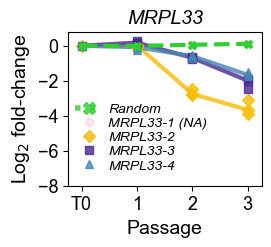

In [33]:
plt.figure(figsize=(2.5,2))

#plt.plot(x_vals_data_points, sg218_data_points_ATC, 'ko', zorder=7, alpha=0.8)
#plt.plot(x_vals_median, sg218_data_points_ATC_line, 'k', zorder=7, alpha=0.8, lw=3)

#plt.plot(x_vals_data_points, sg218_data_points_noATC, marker='o', color='#E31964', linestyle='none', alpha=0.8, zorder=8)
#plt.plot(x_vals_median, sg218_data_points_NoATC_line, color='#E31964', alpha=0.8, lw=3, zorder=8)




plt.plot(x_vals_data_points, sg222_data_points_noATC, marker='D', color='#F7BC04', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg222_data_points_NoATC_line, color='#F7BC04', alpha=0.8, lw=3)




plt.plot(x_vals_data_points, sg223_data_points_noATC, marker='s', color='#492690', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg223_data_points_NoATC_line, color='#492690', alpha=0.8, lw=3)


plt.plot(x_vals_data_points, sg224_data_points_noATC, marker='^', color='#4682B4', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg224_data_points_NoATC_line, color='#4682B4', alpha=0.8, lw=3)

plt.plot(x_vals_median, ctrl_median_datapoints, linestyle='--', marker='X', color='limegreen', zorder=9, lw=3)


plt.xticks([0,1,2,3], ['T0','1', '2', '3'], fontsize=13)
plt.xlabel('Passage', fontsize=14)

plt.ylabel('Log$_{2}$ fold-change', fontsize=14)
plt.yticks(fontsize=13)

plt.xlim(-0.25,3.25)
plt.ylim(-8,0.8)

plt.title('MRPL33', fontsize=14, style='italic')

plt.legend(handles=legend_elements_MRPL33, loc='upper left', fontsize=9, frameon=False, bbox_to_anchor=(-0.025,0.62), labelspacing=0.1, handletextpad =0.35, prop={'style':'italic'})

plt.savefig('./figures/MRPL33_timecourse.svg', format='svg', dpi=300, bbox_inches='tight')


In [34]:
screen_1_counts[screen_1_counts['alias']== 'MMM1'][['Gene', 'alias', 'SgRNA', 'Barcode','WT_0_T0_T0','freq_WT_0_T0_T0', 
                                        'freq_WT_T3_NoATC_1', 'freq_WT_T3_NoATC_2', 'freq_WT_T3_NoATC_3', 
                                        'freq_WT_T3_ATC_1', 'freq_WT_T3_ATC_2', 'freq_WT_T3_ATC_3', 'log2fc_T3_NoATC_3']]

,Gene,alias,SgRNA,Barcode,WT_0_T0_T0,freq_WT_0_T0_T0,freq_WT_T3_NoATC_1,freq_WT_T3_NoATC_2,freq_WT_T3_NoATC_3,freq_WT_T3_ATC_1,freq_WT_T3_ATC_2,freq_WT_T3_ATC_3,log2fc_T3_NoATC_3
262,C4_00560C,MMM1,265,TAGTGCCAGAGATTTCACAG,812.0,0.001765,0.000364,0.000349,0.000379,0.001896,0.001976,0.002019,-2.217704
263,C4_00560C,MMM1,266,AGTGCCAGAGATTTCACAGT,3866.0,0.008393,0.003591,0.003553,0.003372,0.008533,0.008312,0.008066,-1.315744
264,C4_00560C,MMM1,267,TGCCAGAGATTTCACAGTGG,641.0,0.001393,0.000716,0.000623,0.000741,0.001437,0.001328,0.001350,-0.911635
265,C4_00560C,MMM1,268,CCAGAGATTTCACAGTGGGG,538.0,0.001170,0.000009,0.000013,0.000011,0.001110,0.001126,0.000988,-6.675360


In [35]:
sg265_data_points_noATC = [0, 
                         screen_1_counts.at[262,'log2fc_T1_NoATC_1'], screen_1_counts.at[262,'log2fc_T1_NoATC_2'], screen_1_counts.at[262,'log2fc_T1_NoATC_3'],
                         screen_1_counts.at[262,'log2fc_T2_NoATC_1'], screen_1_counts.at[262,'log2fc_T2_NoATC_2'], screen_1_counts.at[262,'log2fc_T2_NoATC_3'],
                         screen_1_counts.at[262,'log2fc_T3_NoATC_1'], screen_1_counts.at[262,'log2fc_T3_NoATC_2'], screen_1_counts.at[262,'log2fc_T3_NoATC_3']]

sg265_data_points_NoATC_line = [0,
                             np.median([screen_1_counts.at[262,'log2fc_T1_NoATC_1'], screen_1_counts.at[262,'log2fc_T1_NoATC_2'], screen_1_counts.at[262,'log2fc_T1_NoATC_3']]),
                             np.median([screen_1_counts.at[262,'log2fc_T2_NoATC_1'], screen_1_counts.at[262,'log2fc_T2_NoATC_2'], screen_1_counts.at[262,'log2fc_T2_NoATC_3']]),
                             np.median([screen_1_counts.at[262,'log2fc_T3_NoATC_1'], screen_1_counts.at[262,'log2fc_T3_NoATC_2'], screen_1_counts.at[262,'log2fc_T3_NoATC_3']])]

In [36]:
sg266_data_points_noATC = [0, 
                         screen_1_counts.at[263,'log2fc_T1_NoATC_1'], screen_1_counts.at[263,'log2fc_T1_NoATC_2'], screen_1_counts.at[263,'log2fc_T1_NoATC_3'],
                         screen_1_counts.at[263,'log2fc_T2_NoATC_1'], screen_1_counts.at[263,'log2fc_T2_NoATC_2'], screen_1_counts.at[263,'log2fc_T2_NoATC_3'],
                         screen_1_counts.at[263,'log2fc_T3_NoATC_1'], screen_1_counts.at[263,'log2fc_T3_NoATC_2'], screen_1_counts.at[263,'log2fc_T3_NoATC_3']]

sg266_data_points_NoATC_line = [0,
                             np.median([screen_1_counts.at[263,'log2fc_T1_NoATC_1'], screen_1_counts.at[263,'log2fc_T1_NoATC_2'], screen_1_counts.at[263,'log2fc_T1_NoATC_3']]),
                             np.median([screen_1_counts.at[263,'log2fc_T2_NoATC_1'], screen_1_counts.at[263,'log2fc_T2_NoATC_2'], screen_1_counts.at[263,'log2fc_T2_NoATC_3']]),
                             np.median([screen_1_counts.at[263,'log2fc_T3_NoATC_1'], screen_1_counts.at[263,'log2fc_T3_NoATC_2'], screen_1_counts.at[263,'log2fc_T3_NoATC_3']])]

In [37]:
sg267_data_points_noATC = [0, 
                         screen_1_counts.at[264,'log2fc_T1_NoATC_1'], screen_1_counts.at[264,'log2fc_T1_NoATC_2'], screen_1_counts.at[264,'log2fc_T1_NoATC_3'],
                         screen_1_counts.at[264,'log2fc_T2_NoATC_1'], screen_1_counts.at[264,'log2fc_T2_NoATC_2'], screen_1_counts.at[264,'log2fc_T2_NoATC_3'],
                         screen_1_counts.at[264,'log2fc_T3_NoATC_1'], screen_1_counts.at[264,'log2fc_T3_NoATC_2'], screen_1_counts.at[264,'log2fc_T3_NoATC_3']]

sg267_data_points_NoATC_line = [0,
                             np.median([screen_1_counts.at[264,'log2fc_T1_NoATC_1'], screen_1_counts.at[264,'log2fc_T1_NoATC_2'], screen_1_counts.at[264,'log2fc_T1_NoATC_3']]),
                             np.median([screen_1_counts.at[264,'log2fc_T2_NoATC_1'], screen_1_counts.at[264,'log2fc_T2_NoATC_2'], screen_1_counts.at[264,'log2fc_T2_NoATC_3']]),
                             np.median([screen_1_counts.at[264,'log2fc_T3_NoATC_1'], screen_1_counts.at[264,'log2fc_T3_NoATC_2'], screen_1_counts.at[264,'log2fc_T3_NoATC_3']])]

In [38]:
sg268_data_points_noATC = [0, 
                         screen_1_counts.at[265,'log2fc_T1_NoATC_1'], screen_1_counts.at[265,'log2fc_T1_NoATC_2'], screen_1_counts.at[265,'log2fc_T1_NoATC_3'],
                         screen_1_counts.at[265,'log2fc_T2_NoATC_1'], screen_1_counts.at[265,'log2fc_T2_NoATC_2'], screen_1_counts.at[265,'log2fc_T2_NoATC_3'],
                         screen_1_counts.at[265,'log2fc_T3_NoATC_1'], screen_1_counts.at[265,'log2fc_T3_NoATC_2'], screen_1_counts.at[265,'log2fc_T3_NoATC_3']]

sg268_data_points_NoATC_line = [0,
                             np.median([screen_1_counts.at[265,'log2fc_T1_NoATC_1'], screen_1_counts.at[265,'log2fc_T1_NoATC_2'], screen_1_counts.at[265,'log2fc_T1_NoATC_3']]),
                             np.median([screen_1_counts.at[265,'log2fc_T2_NoATC_1'], screen_1_counts.at[265,'log2fc_T2_NoATC_2'], screen_1_counts.at[265,'log2fc_T2_NoATC_3']]),
                             np.median([screen_1_counts.at[265,'log2fc_T3_NoATC_1'], screen_1_counts.at[265,'log2fc_T3_NoATC_2'], screen_1_counts.at[265,'log2fc_T3_NoATC_3']])]

In [39]:
legend_elements_MMM1 = [#Line2D([0], [0], color='k', lw=4, alpha=0.8, label='CRISPRi OFF'),
                   #Line2D([0], [0], color='steelblue', lw=4, alpha=0.8, label='CRISPRi ON'),
                   Line2D([0], [0], color='limegreen', marker='X', markersize=8, lw=4, linestyle='dotted', alpha=0.8, label='Random'),
                   Line2D([0], [0], marker='o', color='#E31964', markerfacecolor='#E31964', markersize=6, lw=0, alpha=0.8, label='MMM1-1'),
                   Line2D([0], [0], marker='D', color='#F7BC04', markerfacecolor='#F7BC04',  markersize=6, lw=0, alpha=0.8, label='MMM1-2'),
                   Line2D([0], [0], marker='s', color='#492690', markerfacecolor='#492690',  markersize=6, lw=0, alpha=0.8, label='MMM1-3'),
                   Line2D([0], [0], marker='^', color='#4682B4', markerfacecolor='#4682B4',  markersize=6, lw=0, alpha=0.8, label='MMM1-4')]

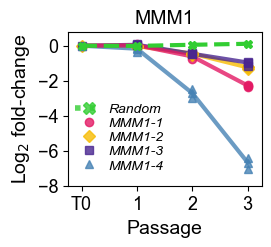

In [40]:
plt.figure(figsize=(2.5,2))



plt.plot(x_vals_data_points, sg265_data_points_noATC, marker='o', color='#E31964', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg265_data_points_NoATC_line, color='#E31964', alpha=0.8, lw=3, zorder=8)


plt.plot(x_vals_data_points, sg266_data_points_noATC, marker='D', color='#F7BC04', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg266_data_points_NoATC_line, color='#F7BC04', alpha=0.8, lw=3)




plt.plot(x_vals_data_points, sg267_data_points_noATC, marker='s', color='#492690', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg267_data_points_NoATC_line, color='#492690', alpha=0.8, lw=3)



plt.plot(x_vals_data_points, sg268_data_points_noATC, marker='^', color='#4682B4', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg268_data_points_NoATC_line, color='#4682B4', alpha=0.8, lw=3)

plt.plot(x_vals_median, ctrl_median_datapoints, linestyle='--', marker='X', color='limegreen', zorder=9, lw=3)


plt.xticks([0,1,2,3], ['T0','1', '2', '3'], fontsize=13)
plt.xlabel('Passage', fontsize=14)

plt.ylabel('Log$_{2}$ fold-change', fontsize=14)
plt.yticks(fontsize=13)

plt.xlim(-0.25,3.25)
plt.ylim(-8,0.8)

plt.title('MMM1', fontsize=14)

plt.legend(handles=legend_elements_MMM1, loc='upper left', fontsize=9, frameon=False, bbox_to_anchor=(-0.025,0.62), labelspacing=0.1, handletextpad =0.35, prop={'style':'italic'})

plt.savefig('./figures/MMM1_timecourse.svg', format='svg', dpi=300, bbox_inches='tight')


In [41]:
screen_1_counts[screen_1_counts['alias']== 'ASK1'][['Gene', 'alias', 'SgRNA', 'Barcode','WT_0_T0_T0','freq_WT_0_T0_T0', 
                                        'freq_WT_T3_NoATC_1', 'freq_WT_T3_NoATC_2', 'freq_WT_T3_NoATC_3', 
                                        'freq_WT_T3_ATC_1', 'freq_WT_T3_ATC_2', 'freq_WT_T3_ATC_3', 'log2fc_T3_NoATC_3']]

,Gene,alias,SgRNA,Barcode,WT_0_T0_T0,freq_WT_0_T0_T0,freq_WT_T3_NoATC_1,freq_WT_T3_NoATC_2,freq_WT_T3_NoATC_3,freq_WT_T3_ATC_1,freq_WT_T3_ATC_2,freq_WT_T3_ATC_3,log2fc_T3_NoATC_3
270,C4_01150W,ASK1,273,GTGTGTTTAAGGGATGCTGG,313.0,0.000682,0.000498,0.000576,0.000553,0.000620,0.000727,0.000768,-0.302314
271,C4_01150W,ASK1,274,TGGTGGTAAATGGTTAGTGG,1600.0,0.003475,0.000413,0.000354,0.000414,0.002412,0.002295,0.002250,-3.070337
272,C4_01150W,ASK1,275,AAATGGTTAGTGGTGGTAAG,221.0,0.000482,0.000060,0.000045,0.000051,0.000218,0.000194,0.000164,-3.248793
273,C4_01150W,ASK1,276,TTAGTGGTGGTAAGTGGAGG,51.0,0.000113,0.000039,0.000024,0.000036,0.000028,0.000055,0.000035,-1.649581


In [42]:
sg273_data_points_noATC = [0, 
                         screen_1_counts.at[270,'log2fc_T1_NoATC_1'], screen_1_counts.at[270,'log2fc_T1_NoATC_2'], screen_1_counts.at[270,'log2fc_T1_NoATC_3'],
                         screen_1_counts.at[270,'log2fc_T2_NoATC_1'], screen_1_counts.at[270,'log2fc_T2_NoATC_2'], screen_1_counts.at[270,'log2fc_T2_NoATC_3'],
                         screen_1_counts.at[270,'log2fc_T3_NoATC_1'], screen_1_counts.at[270,'log2fc_T3_NoATC_2'], screen_1_counts.at[270,'log2fc_T3_NoATC_3']]

sg273_data_points_NoATC_line = [0,
                             np.median([screen_1_counts.at[270,'log2fc_T1_NoATC_1'], screen_1_counts.at[270,'log2fc_T1_NoATC_2'], screen_1_counts.at[270,'log2fc_T1_NoATC_3']]),
                             np.median([screen_1_counts.at[270,'log2fc_T2_NoATC_1'], screen_1_counts.at[270,'log2fc_T2_NoATC_2'], screen_1_counts.at[270,'log2fc_T2_NoATC_3']]),
                             np.median([screen_1_counts.at[270,'log2fc_T3_NoATC_1'], screen_1_counts.at[270,'log2fc_T3_NoATC_2'], screen_1_counts.at[270,'log2fc_T3_NoATC_3']])]



In [43]:
sg274_data_points_noATC = [0, 
                         screen_1_counts.at[271,'log2fc_T1_NoATC_1'], screen_1_counts.at[271,'log2fc_T1_NoATC_2'], screen_1_counts.at[271,'log2fc_T1_NoATC_3'],
                         screen_1_counts.at[271,'log2fc_T2_NoATC_1'], screen_1_counts.at[271,'log2fc_T2_NoATC_2'], screen_1_counts.at[271,'log2fc_T2_NoATC_3'],
                         screen_1_counts.at[271,'log2fc_T3_NoATC_1'], screen_1_counts.at[271,'log2fc_T3_NoATC_2'], screen_1_counts.at[271,'log2fc_T3_NoATC_3']]

sg274_data_points_NoATC_line = [0,
                             np.median([screen_1_counts.at[271,'log2fc_T1_NoATC_1'], screen_1_counts.at[271,'log2fc_T1_NoATC_2'], screen_1_counts.at[271,'log2fc_T1_NoATC_3']]),
                             np.median([screen_1_counts.at[271,'log2fc_T2_NoATC_1'], screen_1_counts.at[271,'log2fc_T2_NoATC_2'], screen_1_counts.at[271,'log2fc_T2_NoATC_3']]),
                             np.median([screen_1_counts.at[271,'log2fc_T3_NoATC_1'], screen_1_counts.at[271,'log2fc_T3_NoATC_2'], screen_1_counts.at[271,'log2fc_T3_NoATC_3']])]

In [44]:
sg275_data_points_noATC = [0, 
                         screen_1_counts.at[272,'log2fc_T1_NoATC_1'], screen_1_counts.at[272,'log2fc_T1_NoATC_2'], screen_1_counts.at[272,'log2fc_T1_NoATC_3'],
                         screen_1_counts.at[272,'log2fc_T2_NoATC_1'], screen_1_counts.at[272,'log2fc_T2_NoATC_2'], screen_1_counts.at[272,'log2fc_T2_NoATC_3'],
                         screen_1_counts.at[272,'log2fc_T3_NoATC_1'], screen_1_counts.at[272,'log2fc_T3_NoATC_2'], screen_1_counts.at[272,'log2fc_T3_NoATC_3']]

sg275_data_points_NoATC_line = [0,
                             np.median([screen_1_counts.at[272,'log2fc_T1_NoATC_1'], screen_1_counts.at[272,'log2fc_T1_NoATC_2'], screen_1_counts.at[272,'log2fc_T1_NoATC_3']]),
                             np.median([screen_1_counts.at[272,'log2fc_T2_NoATC_1'], screen_1_counts.at[272,'log2fc_T2_NoATC_2'], screen_1_counts.at[272,'log2fc_T2_NoATC_3']]),
                             np.median([screen_1_counts.at[272,'log2fc_T3_NoATC_1'], screen_1_counts.at[272,'log2fc_T3_NoATC_2'], screen_1_counts.at[272,'log2fc_T3_NoATC_3']])]

In [45]:
sg276_data_points_noATC = [0, 
                         screen_1_counts.at[273,'log2fc_T1_NoATC_1'], screen_1_counts.at[273,'log2fc_T1_NoATC_2'], screen_1_counts.at[273,'log2fc_T1_NoATC_3'],
                         screen_1_counts.at[273,'log2fc_T2_NoATC_1'], screen_1_counts.at[273,'log2fc_T2_NoATC_2'], screen_1_counts.at[273,'log2fc_T2_NoATC_3'],
                         screen_1_counts.at[273,'log2fc_T3_NoATC_1'], screen_1_counts.at[273,'log2fc_T3_NoATC_2'], screen_1_counts.at[273,'log2fc_T3_NoATC_3']]

sg276_data_points_NoATC_line = [0,
                             np.median([screen_1_counts.at[273,'log2fc_T1_NoATC_1'], screen_1_counts.at[273,'log2fc_T1_NoATC_2'], screen_1_counts.at[273,'log2fc_T1_NoATC_3']]),
                             np.median([screen_1_counts.at[273,'log2fc_T2_NoATC_1'], screen_1_counts.at[273,'log2fc_T2_NoATC_2'], screen_1_counts.at[273,'log2fc_T2_NoATC_3']]),
                             np.median([screen_1_counts.at[273,'log2fc_T3_NoATC_1'], screen_1_counts.at[273,'log2fc_T3_NoATC_2'], screen_1_counts.at[273,'log2fc_T3_NoATC_3']])]

In [46]:
legend_elements_ASK1 = [#Line2D([0], [0], color='k', lw=4, alpha=0.8, label='CRISPRi OFF'),
                   #Line2D([0], [0], color='steelblue', lw=4, alpha=0.8, label='CRISPRi ON'),
                   Line2D([0], [0], color='limegreen', marker='X', markersize=8, lw=4, linestyle='dotted', alpha=0.8, label='Random'),
                   Line2D([0], [0], marker='o', color='#E31964', markerfacecolor='#E31964', markersize=6, lw=0, alpha=0.8, label='ASK1-1'),
                   Line2D([0], [0], marker='D', color='#F7BC04', markerfacecolor='#F7BC04', markersize=6, lw=0, alpha=0.8, label='ASK1-2'),
                   Line2D([0], [0], marker='s', color='#492690', markerfacecolor='#492690', markersize=6, lw=0, alpha=0.8, label='ASK1-3'),
                   Line2D([0], [0], marker='^', color='#4682B4', markerfacecolor='#4682B4', markersize=6, lw=0, alpha=0.8, label='ASK1-4')]

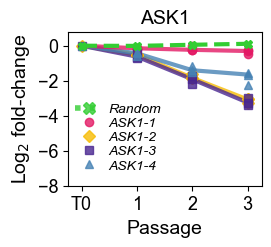

In [47]:
plt.figure(figsize=(2.5,2))

plt.plot(x_vals_data_points, sg273_data_points_noATC, marker='o', color='#E31964', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg273_data_points_NoATC_line, color='#E31964', alpha=0.8, lw=3, zorder=8)


plt.plot(x_vals_data_points, sg274_data_points_noATC, marker='D', color='#F7BC04', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg274_data_points_NoATC_line, color='#F7BC04', alpha=0.8, lw=3)


plt.plot(x_vals_data_points, sg275_data_points_noATC, marker='s', color='#492690', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg275_data_points_NoATC_line, color='#492690', alpha=0.8, lw=3)


plt.plot(x_vals_data_points, sg276_data_points_noATC, marker='^', color='#4682B4', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg276_data_points_NoATC_line, color='#4682B4', alpha=0.8, lw=3)

plt.plot(x_vals_median, ctrl_median_datapoints, linestyle='--', marker='X', color='limegreen', zorder=9, lw=3)


plt.xticks([0,1,2,3], ['T0','1', '2', '3'], fontsize=13)
plt.xlabel('Passage', fontsize=14)

plt.ylabel('Log$_{2}$ fold-change', fontsize=14)
plt.yticks(fontsize=13)

plt.xlim(-0.25,3.25)
plt.ylim(-8,0.8)

plt.title('ASK1', fontsize=14)

plt.legend(handles=legend_elements_ASK1, loc='upper left', fontsize=9, frameon=False, bbox_to_anchor=(-0.025,0.62), labelspacing=0.1, handletextpad =0.35, prop={'style':'italic'})

plt.savefig('./figures/ASK1_timecourse.svg', format='svg', dpi=300, bbox_inches='tight')

In [48]:
is_control = screen_1_counts['control'] == 1
is_test = screen_1_counts['control'] == 0

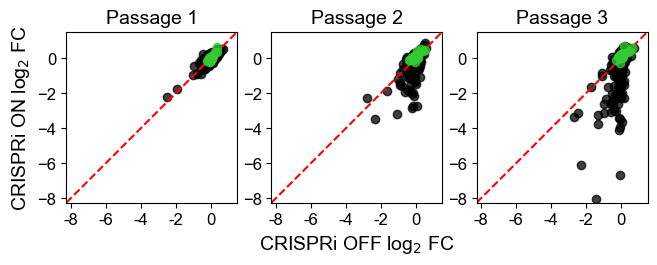

In [49]:
plt.figure(figsize=(7.5,3))

plt.subplot(131, aspect='equal')
plt.scatter(screen_1_counts[is_control]['median_log2fc_ATC_T1'], screen_1_counts[is_control]['median_log2fc_NoATC_T1'], color='limegreen',zorder=9, alpha=0.75)
plt.scatter(screen_1_counts[is_test]['median_log2fc_ATC_T1'], screen_1_counts[is_test]['median_log2fc_NoATC_T1'], color='k', alpha=0.75)

plt.plot([-8.25,1.5], [-8.25,1.5], 'r--')

plt.xlim(-8.25,1.5)
plt.ylim(-8.25,1.5)

plt.ylabel('CRISPRi ON log${_2}$ FC', fontsize=14)
plt.title('Passage 1', fontsize=14)
plt.xticks([-8,-6,-4,-2, 0],[-8,-6,-4,-2, 0],fontsize=12)
plt.yticks(fontsize=12)

#############################
plt.subplot(132, aspect='equal')
plt.scatter(screen_1_counts[is_control]['median_log2fc_ATC_T2'], screen_1_counts[is_control]['median_log2fc_NoATC_T2'], color='limegreen',zorder=9, alpha=0.75)
plt.scatter(screen_1_counts[is_test]['median_log2fc_ATC_T2'], screen_1_counts[is_test]['median_log2fc_NoATC_T2'], color='k', alpha=0.75)

plt.plot([-8.25,1.5], [-8.25,1.5], 'r--')

plt.xlabel('CRISPRi OFF log${_2}$ FC', fontsize=14, )
plt.title('Passage 2', fontsize=14)
plt.xticks([-8,-6,-4,-2, 0],[-8,-6,-4,-2, 0],fontsize=12)
plt.yticks(fontsize=12)

plt.xlim(-8.25,1.5)
plt.ylim(-8.25,1.5)

#############################
ax = plt.subplot(133, aspect='equal')
plt.scatter(screen_1_counts[is_control]['median_log2fc_ATC_T3'], screen_1_counts[is_control]['median_log2fc_NoATC_T3'], color='limegreen',zorder=9, alpha=0.75)
plt.scatter(screen_1_counts[is_test]['median_log2fc_ATC_T3'], screen_1_counts[is_test]['median_log2fc_NoATC_T3'], color='k', alpha=0.75)

plt.plot([-8.25,1.5], [-8.25,1.5], 'r--')



plt.xlim(-8.25,1.5)
plt.ylim(-8.25,1.5)
plt.title('Passage 3', fontsize=14)
plt.xticks([-8,-6,-4,-2, 0],[-8,-6,-4,-2, 0],fontsize=12)
plt.yticks(fontsize=12)


plt.savefig('./figures/timecourse.svg', format='svg', dpi=300)



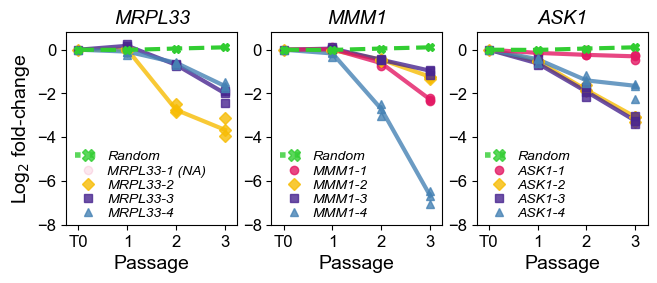

In [50]:
plt.figure(figsize=(7.5,2.5))

######### MRPL33
plt.subplot(131)


plt.plot(x_vals_data_points, sg222_data_points_noATC, marker='D', color='#F7BC04', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg222_data_points_NoATC_line, color='#F7BC04', alpha=0.8, lw=3)



plt.plot(x_vals_data_points, sg223_data_points_noATC, marker='s', color='#492690', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg223_data_points_NoATC_line, color='#492690', alpha=0.8, lw=3)


plt.plot(x_vals_data_points, sg224_data_points_noATC, marker='^', color='#4682B4', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg224_data_points_NoATC_line, color='#4682B4', alpha=0.8, lw=3)

plt.plot(x_vals_median, ctrl_median_datapoints, linestyle='--', marker='X', color='limegreen', zorder=9, lw=3)


plt.xticks([0,1,2,3], ['T0','1', '2', '3'], fontsize=12)
plt.xlabel('Passage', fontsize=14)

plt.ylabel('Log$_{2}$ fold-change', fontsize=14)
plt.yticks(fontsize=12)

plt.xlim(-0.25,3.25)
plt.ylim(-8,0.8)

plt.title('MRPL33', fontsize=14, style='italic')

plt.legend(handles=legend_elements_MRPL33, loc='upper left', fontsize=10, frameon=False, bbox_to_anchor=(-0.025,0.45), labelspacing=0.1, handletextpad =0.35, prop={'style':'italic'})

######### MMM1
plt.subplot(132)

plt.plot(x_vals_data_points, sg265_data_points_noATC, marker='o', color='#E31964', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg265_data_points_NoATC_line, color='#E31964', alpha=0.8, lw=3, zorder=8)

plt.plot(x_vals_data_points, sg266_data_points_noATC, marker='D', color='#F7BC04', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg266_data_points_NoATC_line, color='#F7BC04', alpha=0.8, lw=3)

plt.plot(x_vals_data_points, sg267_data_points_noATC, marker='s', color='#492690', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg267_data_points_NoATC_line, color='#492690', alpha=0.8, lw=3)

plt.plot(x_vals_data_points, sg268_data_points_noATC, marker='^', color='#4682B4', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg268_data_points_NoATC_line, color='#4682B4', alpha=0.8, lw=3)

plt.plot(x_vals_median, ctrl_median_datapoints, linestyle='--', marker='X', color='limegreen', zorder=9, lw=3)


plt.xticks([0,1,2,3], ['T0','1', '2', '3'], fontsize=12)
plt.xlabel('Passage', fontsize=14)

plt.yticks(fontsize=12)

plt.xlim(-0.25,3.25)
plt.ylim(-8,0.8)

plt.title('MMM1', fontsize=14, style='italic')

plt.legend(handles=legend_elements_MMM1, loc='upper left', fontsize=10, frameon=False, bbox_to_anchor=(-0.025,0.45), labelspacing=0.1, handletextpad =0.35, prop={'style':'italic'})


######################### ASK1
plt.subplot(133)


plt.plot(x_vals_data_points, sg273_data_points_noATC, marker='o', color='#E31964', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg273_data_points_NoATC_line, color='#E31964', alpha=0.8, lw=3, zorder=8)

plt.plot(x_vals_data_points, sg274_data_points_noATC, marker='D', color='#F7BC04', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg274_data_points_NoATC_line, color='#F7BC04', alpha=0.8, lw=3)

plt.plot(x_vals_data_points, sg275_data_points_noATC, marker='s', color='#492690', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg275_data_points_NoATC_line, color='#492690', alpha=0.8, lw=3)

plt.plot(x_vals_data_points, sg276_data_points_noATC, marker='^', color='#4682B4', linestyle='none', alpha=0.8, zorder=8)
plt.plot(x_vals_median, sg276_data_points_NoATC_line, color='#4682B4', alpha=0.8, lw=3)

plt.plot(x_vals_median, ctrl_median_datapoints, linestyle='--', marker='X', color='limegreen', zorder=9, lw=3)


plt.xticks([0,1,2,3], ['T0','1', '2', '3'], fontsize=12)
plt.xlabel('Passage', fontsize=14)

plt.yticks(fontsize=12)

plt.xlim(-0.25,3.25)
plt.ylim(-8,0.8)

plt.title('ASK1', fontsize=14, style='italic')

plt.legend(handles=legend_elements_ASK1, loc='upper left', fontsize=10, frameon=False, bbox_to_anchor=(-0.025,0.45), labelspacing=0.1, handletextpad =0.35, prop={'style':'italic'})

plt.savefig('./figures/individal_sgRNAs.svg', format='svg', dpi=300)


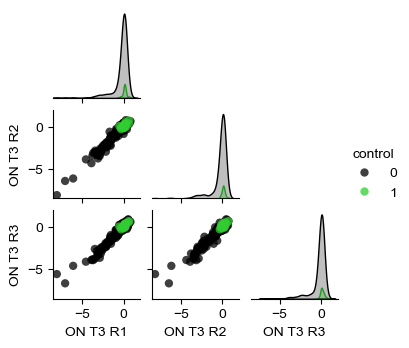

In [51]:

p = sns.pairplot(screen_1_counts[is_control|is_test], vars =['log2fc_T3_NoATC_1_filter',  'log2fc_T3_NoATC_2_filter', 'log2fc_T3_NoATC_3_filter'], diag_kind='kde', corner=True,
                hue='control', palette={1:'limegreen',0:'k'}, plot_kws={'linewidth':0, 'alpha':0.75}, height=3.5/3)
p.set(xlim=(-8.5,2), ylim=(-8.5,2))

p.x_vars = ['ON T3 R1', 'ON T3 R2', 'ON T3 R3']
p.y_vars = ['ON T3 R1', 'ON T3 R2', 'ON T3 R3']
p._add_axis_labels()

plt.savefig('./figures/timecourse_rep_scatterplot_ON_T3_screen_1.svg', dpi=300)

In [52]:
stats.spearmanr(screen_1_counts[is_control|is_test]['log2fc_T3_NoATC_1_filter'],screen_1_counts[is_control|is_test]['log2fc_T3_NoATC_2_filter'], nan_policy='omit'), len(screen_1_counts[is_control|is_test][['log2fc_T3_NoATC_1_filter', 'log2fc_T3_NoATC_2_filter']].dropna())

(SignificanceResult(statistic=0.8429142966180352, pvalue=2.9753435046539188e-127),
 467)

In [53]:
len(screen_1_counts[is_control][['log2fc_T3_NoATC_1_filter', 'log2fc_T3_NoATC_2_filter']].dropna()), len(screen_1_counts[is_test][['log2fc_T3_NoATC_1_filter', 'log2fc_T3_NoATC_2_filter']].dropna())

(29, 438)

In [54]:
stats.spearmanr(screen_1_counts[is_control|is_test]['log2fc_T3_NoATC_1_filter'],screen_1_counts[is_control|is_test]['log2fc_T3_NoATC_3_filter'], nan_policy='omit'), len(screen_1_counts[is_control|is_test][['log2fc_T3_NoATC_1_filter', 'log2fc_T3_NoATC_3_filter']].dropna())

(SignificanceResult(statistic=0.8273187114666681, pvalue=1.5178623417687034e-118),
 467)

In [55]:
stats.spearmanr(screen_1_counts[is_control|is_test]['log2fc_T3_NoATC_2_filter'],screen_1_counts[is_control|is_test]['log2fc_T3_NoATC_3_filter'], nan_policy='omit'), len(screen_1_counts[is_control|is_test][['log2fc_T3_NoATC_2_filter', 'log2fc_T3_NoATC_3_filter']].dropna())

(SignificanceResult(statistic=0.8233598842217071, pvalue=1.790825955343703e-116),
 467)

In [56]:
on_mean, on_scale = stats.norm.fit(screen_1_counts[is_control]['median_log2fc_NoATC_T3'].dropna())
on_mean, on_scale

(0.14814748484895832, 0.18847388057226697)

-0.28495656048952966 0.010782243308417327 96 0.2191780821917808 0.04919398509465406


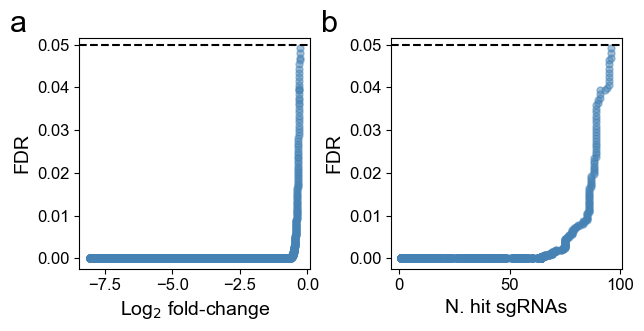

In [57]:
target_col = 'median_log2fc_NoATC_T3'

bins = np.linspace(min(screen_1_counts[target_col].dropna())+0.01, 0, 5000)
#                                                        5000

plt.figure(figsize=(7,3))

ax1 = plt.subplot(122)
ax2 = plt.subplot(121)



for val in bins:

    FPR = stats.norm.cdf(val, loc=on_mean, scale=on_scale)

    positives = len([x for x in screen_1_counts[is_test][target_col] if x < val])
    PR = positives/len(screen_1_counts[is_test][target_col].dropna())

    FDR = FPR/PR
    
    #print(val, FPR, positives, PR, FDR)

    ax1.plot(positives, FDR, marker='o', color='steelblue', ms= 5, alpha=0.5)
    ax2.plot(val, FDR, marker='o', color='steelblue', ms= 5, alpha=0.5)
   

    if FDR >= 0.049:
        #    0.25
        print(val, FPR, positives, PR, FDR)
        break
        
ax1.axhline(0.05, color='k', linestyle='--')
ax1.set_ylabel('FDR', fontsize=14)
ax1.set_xlabel('N. hit sgRNAs', fontsize=14)
ax2.text(-11, 0.053, 'a', fontsize=22)
ax2.text(0.5, 0.053, 'b', fontsize=22)
ax1.tick_params(labelsize=12)

ax2.axhline(0.05, color='k', linestyle='--')
ax2.set_xlabel(r'Log$_{2}$ fold-change', fontsize=14)
ax2.set_ylabel('FDR', fontsize=14)
ax2.tick_params(labelsize=12)


plt.subplots_adjust(wspace=0.35)


plt.savefig('./figures/timecourse_T3_hit_threshold_FDRv2.svg', format='svg', dpi=300, bbox_inches='tight')


In [58]:
len(screen_1_counts[is_control]['median_log2fc_NoATC_T3'].dropna()), len(screen_1_counts[is_test]['median_log2fc_NoATC_T3'].dropna())

(29, 438)

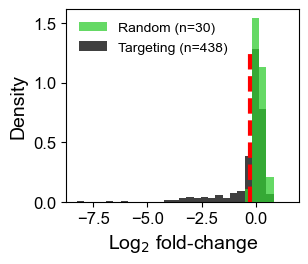

In [59]:
plt.figure(figsize=(3,2.5))

plt.hist(screen_1_counts[is_control]['median_log2fc_NoATC_T3'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.hist(screen_1_counts[is_test]['median_log2fc_NoATC_T3'], color='k', alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.legend(['Random (n=30)', 'Targeting (n=438)'], fontsize=10, loc='upper left', frameon=False, facecolor='white').set_zorder(9)


#x = np.linspace(-8.25,1.5,500)
#plt.plot(x, stats.norm.pdf(x, on_mean, on_scale), 'steelblue', linewidth=3,zorder=9)


plt.xlabel('Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(-0.285, ymin=0, ymax=0.78, color='red', lw=3, linestyle='--', zorder=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('./figures/cumulative_dist.svg', dpi=300, format='svg')

In [60]:
screen_1_counts['delta_ATC_T1'] = screen_1_counts['median_log2fc_NoATC_T1'] - screen_1_counts['median_log2fc_ATC_T1']
screen_1_counts['delta_ATC_T2'] = screen_1_counts['median_log2fc_NoATC_T2'] - screen_1_counts['median_log2fc_ATC_T2']
screen_1_counts['delta_ATC_T3'] = screen_1_counts['median_log2fc_NoATC_T3'] - screen_1_counts['median_log2fc_ATC_T3']

In [61]:
len(screen_1_counts[is_control]['delta_ATC_T1'].dropna()), len(screen_1_counts[is_test]['delta_ATC_T1'].dropna())

(29, 438)

In [62]:
col_list_dist_test = ['median_log2fc_NoATC_T1','median_log2fc_NoATC_T2','median_log2fc_NoATC_T3',
                      'median_log2fc_ATC_T1','median_log2fc_ATC_T2','median_log2fc_ATC_T3',
                      'delta_ATC_T1','delta_ATC_T2','delta_ATC_T3']

-0.49841205606481265 0.00123890077665149 11 0.02511415525114155 0.04933077637939569


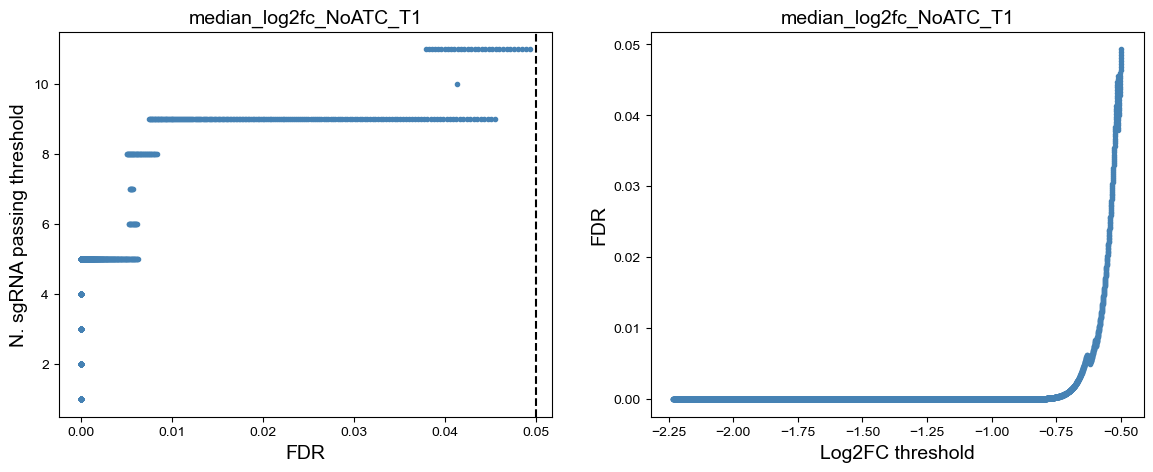

-0.3364701501901237 0.007631046009871501 68 0.1552511415525114 0.04915291400476055


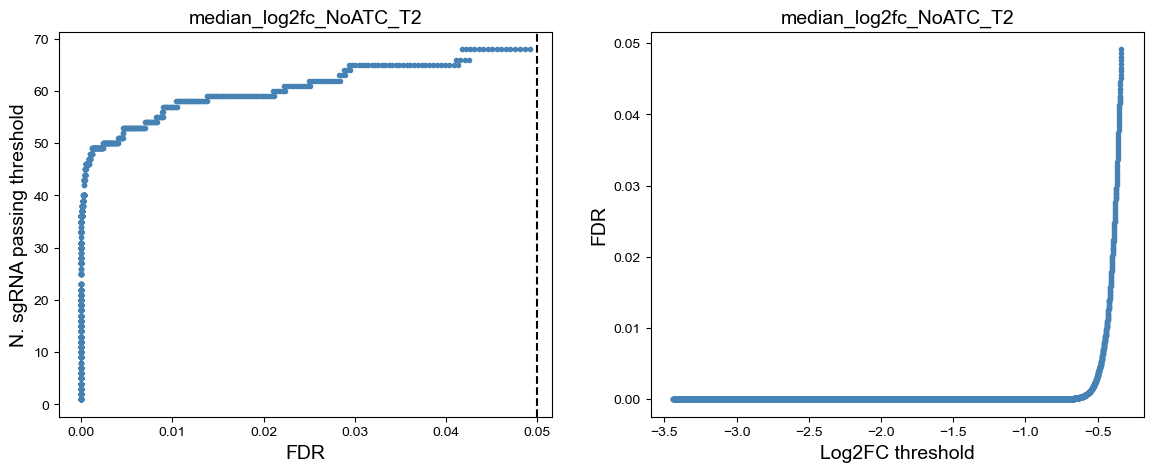

-0.28495656048952966 0.010782243308417327 96 0.2191780821917808 0.04919398509465406


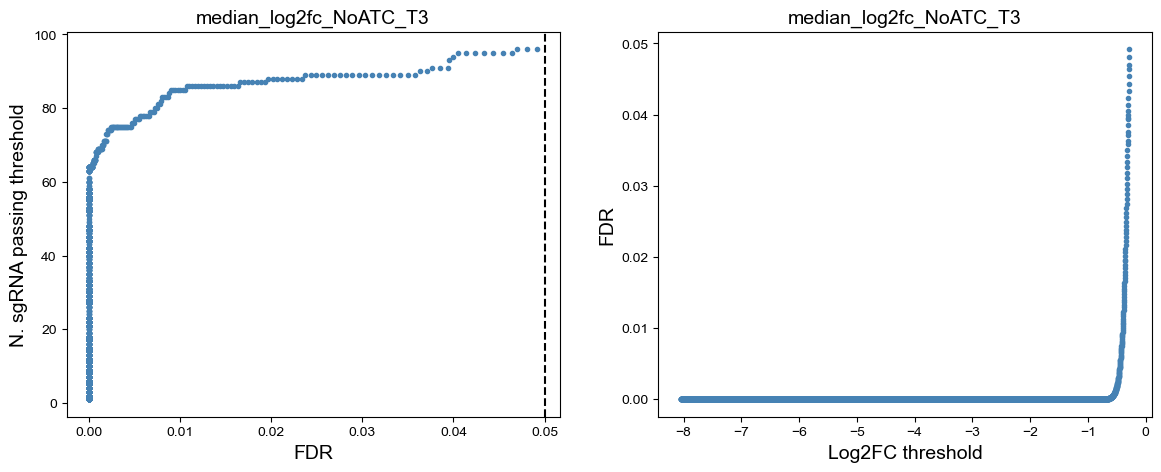

-0.34506617040602094 0.002488378811036263 22 0.0502283105022831 0.049541359965176515


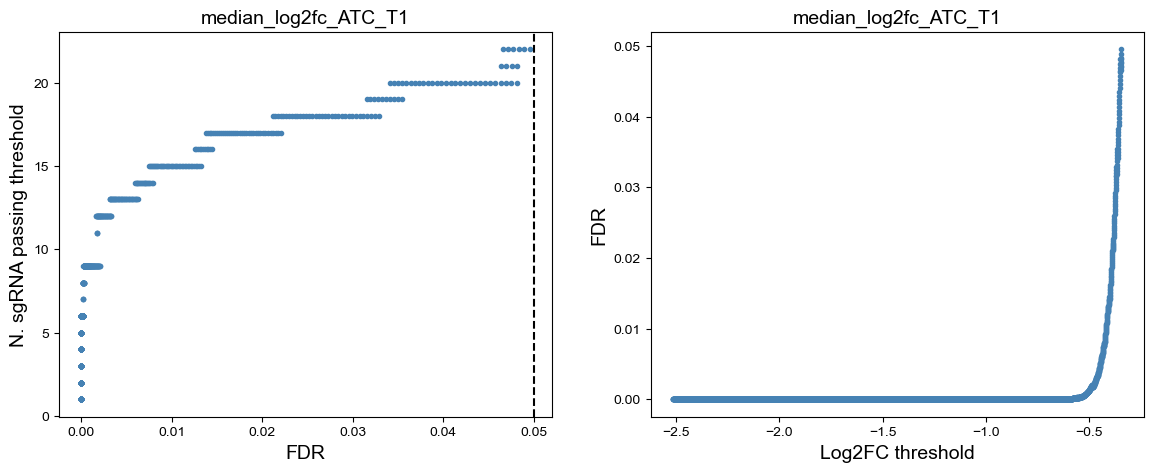

-0.5635898427536081 0.0014650863346113493 13 0.02968036529680365 0.049362139581520845


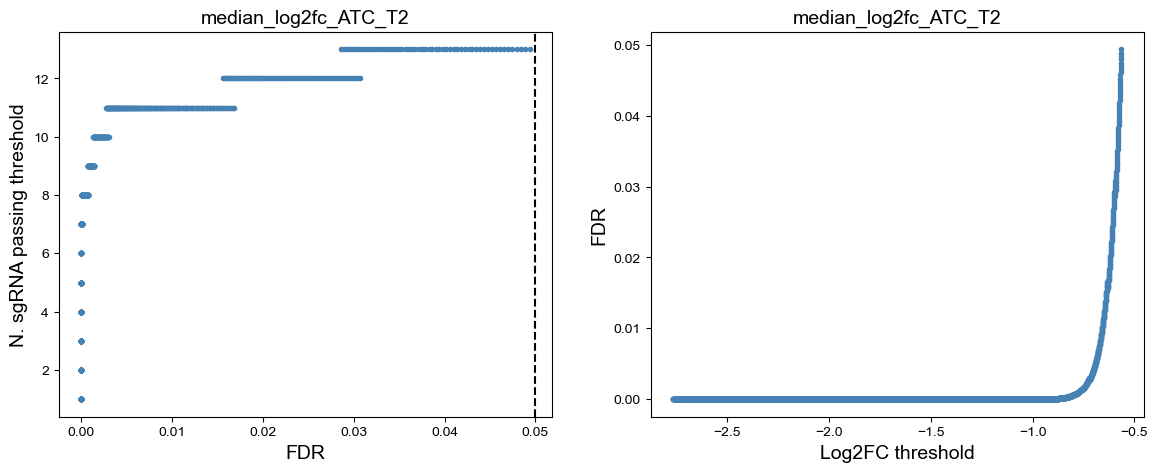

-0.4757862114584177 0.002801781244627675 25 0.05707762557077625 0.04908720740587687


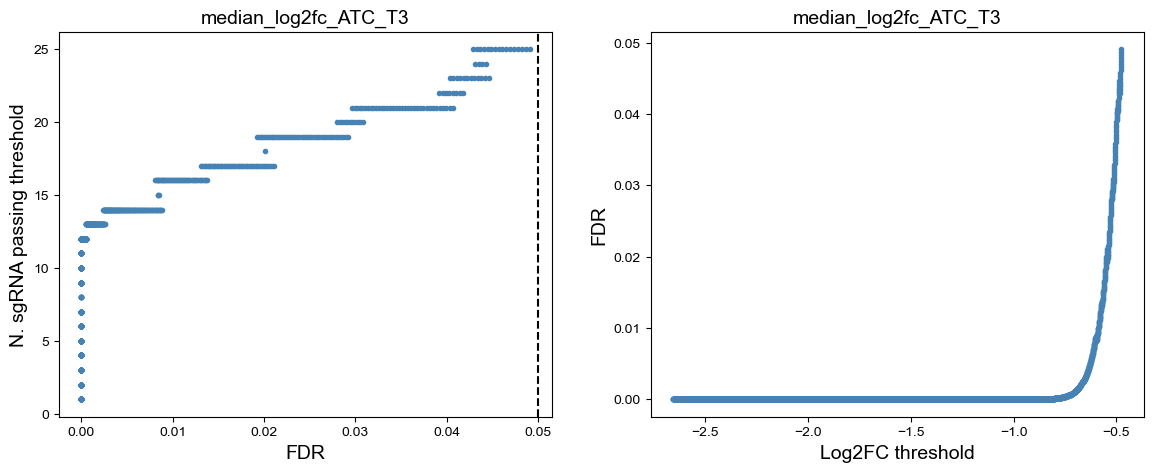

-0.2220720979461781 0.0016818840315308515 15 0.03424657534246575 0.04911101372070087


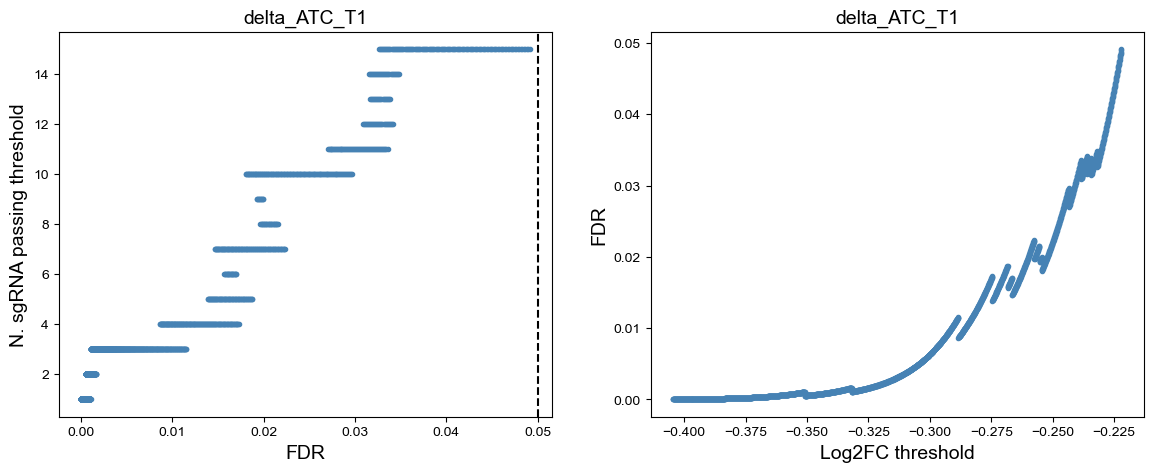

-0.1633128228654277 0.009750624590077979 87 0.19863013698630136 0.049089351384530515


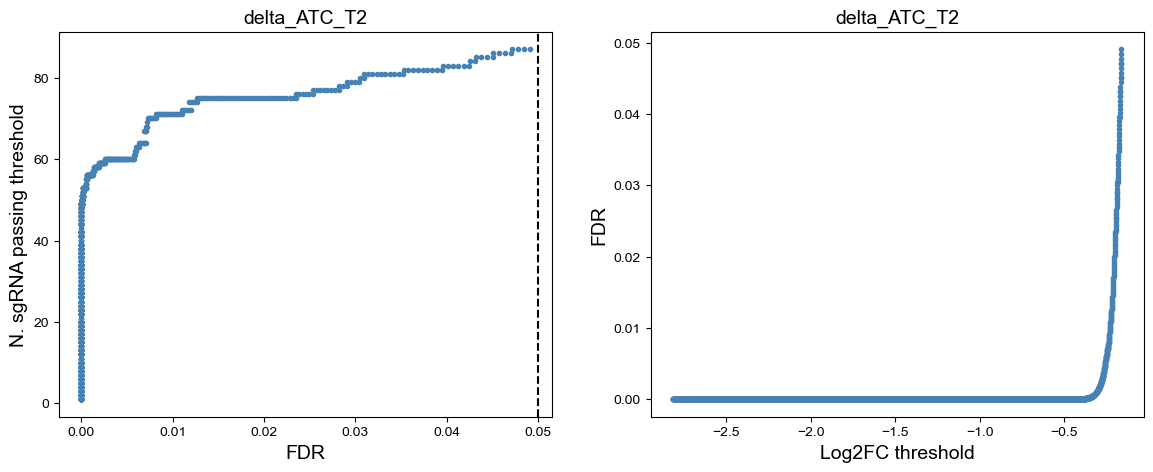

-0.20886611851041437 0.010193487044291955 89 0.20319634703196346 0.05016570028539187


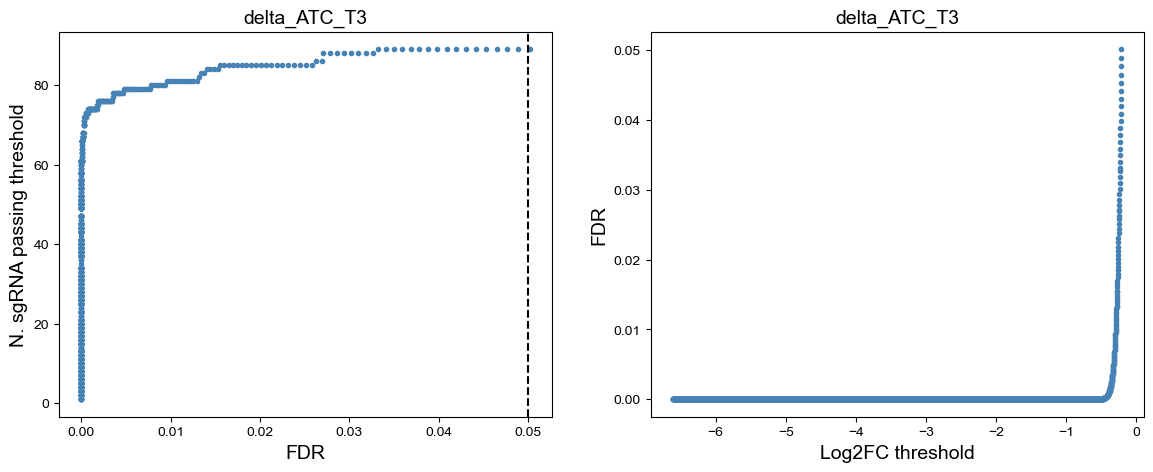

In [63]:
stats_dict_timecourse={}



for col in col_list_dist_test:
    
    bins = np.linspace(min(screen_1_counts[col].dropna())+0.01, 0, 5000)
    #                                                        5000
    
    col_mean, col_scale = stats.norm.fit(screen_1_counts[is_control][col].dropna())


    plt.figure(figsize=(14,5))

    ax1 = plt.subplot(121)
    ax2 = plt.subplot(122)
    
    stats_dict={}


    for val in bins:

        FPR = stats.norm.cdf(val, loc=col_mean, scale=col_scale)

        positives = len([x for x in screen_1_counts[is_test][col] if x < val])
        PR = positives/len(screen_1_counts[is_test][col].dropna())

        FDR = FPR/PR

        #print(val, FPR, positives, PR, FDR)

        ax1.plot(FDR, positives, marker='o', color='steelblue', ms= 3)
        ax2.plot(val, FDR, marker='o', color='steelblue', ms= 3)


        if FDR >= 0.049:
            #    0.25
            print(val, FPR, positives, PR, FDR)
            stats_dict['threshold'] = val
            stats_dict['positives'] = positives

            
            break
        stats_dict_timecourse[col] = stats_dict

    ax1.axvline(0.05, color='k', linestyle='--')
    ax1.set_xlabel('FDR', fontsize=14)
    ax1.set_ylabel('N. sgRNA passing threshold', fontsize=14)
    ax1.set_title(col, fontsize=14)


    ax2.set_xlabel('Log2FC threshold', fontsize=14)
    ax2.set_ylabel('FDR', fontsize=14)
    ax2.set_title(col, fontsize=14)
    plt.show()

In [64]:
stats_dict_timecourse

{'median_log2fc_NoATC_T1': {'threshold': -0.49841205606481265,
  'positives': 11},
 'median_log2fc_NoATC_T2': {'threshold': -0.3364701501901237, 'positives': 68},
 'median_log2fc_NoATC_T3': {'threshold': -0.28495656048952966,
  'positives': 96},
 'median_log2fc_ATC_T1': {'threshold': -0.34506617040602094, 'positives': 22},
 'median_log2fc_ATC_T2': {'threshold': -0.5635898427536081, 'positives': 13},
 'median_log2fc_ATC_T3': {'threshold': -0.4757862114584177, 'positives': 25},
 'delta_ATC_T1': {'threshold': -0.2220720979461781, 'positives': 15},
 'delta_ATC_T2': {'threshold': -0.1633128228654277, 'positives': 87},
 'delta_ATC_T3': {'threshold': -0.20886611851041437, 'positives': 89}}

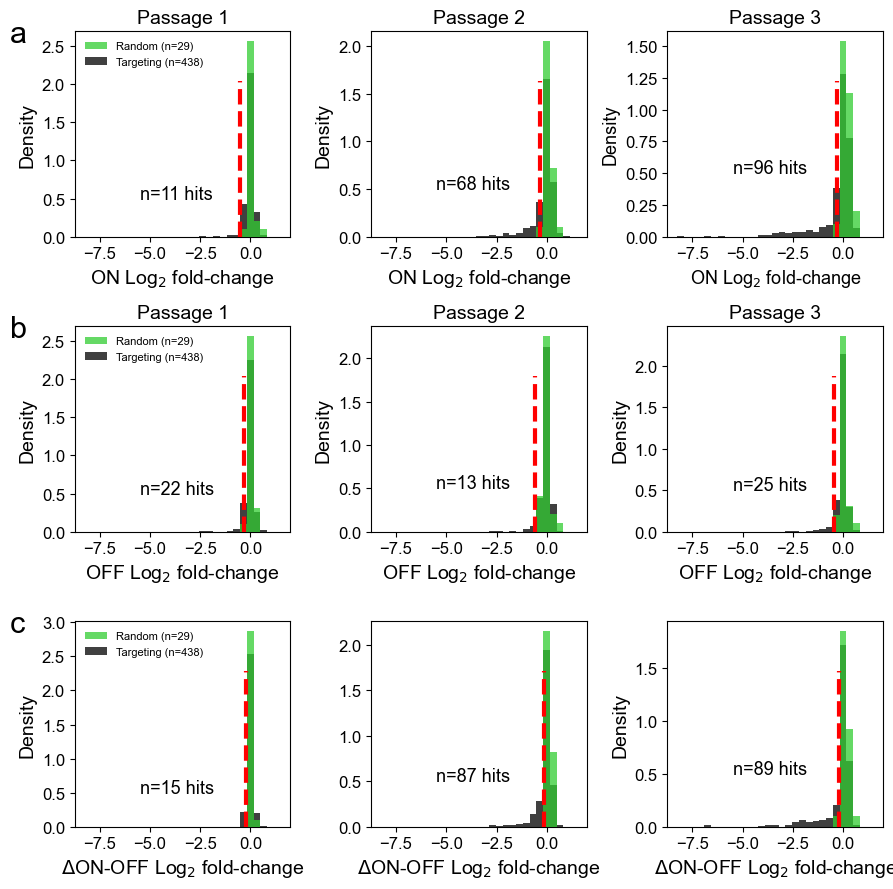

In [65]:

plt.figure(figsize=(9,9))

#########################################
ax1 = plt.subplot(331)

plt.title('Passage 1', fontsize=14)

plt.hist(screen_1_counts[is_control]['median_log2fc_NoATC_T1'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.hist(screen_1_counts[is_test]['median_log2fc_NoATC_T1'], color='k', alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.legend(['Random (n=29)', 'Targeting (n=438)'], fontsize=8, loc='upper left', frameon=False, facecolor='white').set_zorder(9)

plt.xlabel(r'ON Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(stats_dict_timecourse['median_log2fc_NoATC_T1']['threshold'], ymin=0, ymax=0.76, color='red', lw=3, linestyle='--', zorder=10)
plt.text(-5.5,0.5, 'n='+str(stats_dict_timecourse['median_log2fc_NoATC_T1']['positives'])+' hits', fontsize=13)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.text(-0.3,0.95,'a', transform=ax1.transAxes, fontsize=22)

#########################
ax2 = plt.subplot(332)

plt.title('Passage 2', fontsize=14)

plt.hist(screen_1_counts[is_control]['median_log2fc_NoATC_T2'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.hist(screen_1_counts[is_test]['median_log2fc_NoATC_T2'], color='k', alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)

plt.xlabel(r'ON Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(stats_dict_timecourse['median_log2fc_NoATC_T2']['threshold'], ymin=0, ymax=0.76, color='red', lw=3, linestyle='--', zorder=10)
plt.text(-5.5,0.5, 'n='+str(stats_dict_timecourse['median_log2fc_NoATC_T2']['positives'])+' hits', fontsize=13)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)



#########################
ax3 = plt.subplot(333)

plt.title('Passage 3', fontsize=14)

plt.hist(screen_1_counts[is_control]['median_log2fc_NoATC_T3'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.hist(screen_1_counts[is_test]['median_log2fc_NoATC_T3'], color='k', alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)

plt.xlabel(r'ON Log$_{2}$ fold-change', fontsize=13)
plt.ylabel('Density', fontsize=13)

plt.axvline(stats_dict_timecourse['median_log2fc_NoATC_T3']['threshold'], ymin=0, ymax=0.76, color='red', lw=3, linestyle='--', zorder=10)
plt.text(-5.5,0.5, 'n='+str(stats_dict_timecourse['median_log2fc_NoATC_T3']['positives'])+' hits', fontsize=13)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)








#########################################
ax4 = plt.subplot(334)

plt.title('Passage 1', fontsize=14)

plt.hist(screen_1_counts[is_control]['median_log2fc_ATC_T1'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.hist(screen_1_counts[is_test]['median_log2fc_ATC_T1'], color='k', alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.legend(['Random (n=29)', 'Targeting (n=438)'], fontsize=8, loc='upper left', frameon=False, facecolor='white').set_zorder(9)

plt.xlabel(r'OFF Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(stats_dict_timecourse['median_log2fc_ATC_T1']['threshold'], ymin=0, ymax=0.76, color='red', lw=3, linestyle='--', zorder=10)
plt.text(-5.5,0.5, 'n='+str(stats_dict_timecourse['median_log2fc_ATC_T1']['positives'])+' hits', fontsize=13)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.text(-0.3,0.95,'b', transform=ax4.transAxes, fontsize=22)

#########################
ax5 = plt.subplot(335)

plt.title('Passage 2', fontsize=14)

plt.hist(screen_1_counts[is_control]['median_log2fc_ATC_T2'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.hist(screen_1_counts[is_test]['median_log2fc_ATC_T2'], color='k', alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)

plt.xlabel(r'OFF Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(stats_dict_timecourse['median_log2fc_ATC_T2']['threshold'], ymin=0, ymax=0.76, color='red', lw=3, linestyle='--', zorder=10)
plt.text(-5.5,0.5, 'n='+str(stats_dict_timecourse['median_log2fc_ATC_T2']['positives'])+' hits', fontsize=13)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)



#########################
ax6 = plt.subplot(336)

plt.title('Passage 3', fontsize=14)

plt.hist(screen_1_counts[is_control]['median_log2fc_ATC_T3'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.hist(screen_1_counts[is_test]['median_log2fc_ATC_T3'], color='k', alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)

plt.xlabel(r'OFF Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(stats_dict_timecourse['median_log2fc_ATC_T3']['threshold'], ymin=0, ymax=0.76, color='red', lw=3, linestyle='--', zorder=10)
plt.text(-5.5,0.5, 'n='+str(stats_dict_timecourse['median_log2fc_ATC_T3']['positives'])+' hits', fontsize=13)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)








########################################
ax7 = plt.subplot(337)

plt.hist(screen_1_counts[is_control]['delta_ATC_T1'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.hist(screen_1_counts[is_test]['delta_ATC_T1'], color='k', alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.legend(['Random (n=29)', 'Targeting (n=438)'], fontsize=8, loc='upper left', frameon=False, facecolor='white').set_zorder(9)

plt.xlabel(r'$\Delta$ON-OFF Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(stats_dict_timecourse['delta_ATC_T1']['threshold'], ymin=0, ymax=0.76, color='red', lw=3, linestyle='--', zorder=10)
plt.text(-5.5,0.5, 'n='+str(stats_dict_timecourse['delta_ATC_T1']['positives'])+' hits', fontsize=13)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.text(-0.3,0.95,'c', transform=ax7.transAxes, fontsize=22)


#####################################################
ax8 = plt.subplot(338)

plt.hist(screen_1_counts[is_control]['delta_ATC_T2'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.hist(screen_1_counts[is_test]['delta_ATC_T2'], color='k', alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)

plt.axvline(stats_dict_timecourse['delta_ATC_T2']['threshold'], ymin=0, ymax=0.76, color='red', lw=3, linestyle='--', zorder=10)
plt.text(-5.5,0.5, 'n='+str(stats_dict_timecourse['delta_ATC_T2']['positives'])+' hits', fontsize=13)

plt.xlabel(r'$\Delta$ON-OFF Log$_{2}$ fold-change', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)



#####################################################
ax9 = plt.subplot(339)

plt.hist(screen_1_counts[is_control]['delta_ATC_T3'], color='limegreen',zorder=8, alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)
plt.hist(screen_1_counts[is_test]['delta_ATC_T3'], color='k', alpha=0.75, bins = np.linspace(-8.25,1.5,30), density=True)

plt.xlabel(r'$\Delta$ON-OFF Log$_{2}$ fold-change', fontsize=14)
plt.ylabel('Density', fontsize=14)

plt.axvline(stats_dict_timecourse['delta_ATC_T3']['threshold'], ymin=0, ymax=0.76, color='red', lw=3, linestyle='--', zorder=10)
plt.text(-5.5,0.5, 'n='+str(stats_dict_timecourse['delta_ATC_T3']['positives'])+' hits', fontsize=13)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


plt.tight_layout()

plt.savefig('./figures/cumulative_dists_timecourse.svg', dpi=300, format='svg')


In [66]:
below_ON_T3_threshold = screen_1_counts['median_log2fc_NoATC_T3'] < -0.285
below_ON_T3_threshold

0      False
1      False
2      False
3      False
4      False
       ...  
548    False
549    False
550    False
551    False
552     True
Name: median_log2fc_NoATC_T3, Length: 553, dtype: bool

In [67]:
list(screen_1_counts[is_test&below_ON_T3_threshold].alias.value_counts()).count(4), list(screen_1_counts[is_test&below_ON_T3_threshold].alias.value_counts()).count(3), list(screen_1_counts[is_test&below_ON_T3_threshold].alias.value_counts()).count(2), list(screen_1_counts[is_test&below_ON_T3_threshold].alias.value_counts()).count(1)

(3, 9, 8, 41)

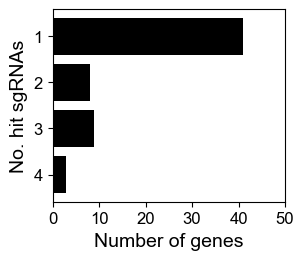

In [68]:
plt.figure(figsize=(3,2.5))

plt.barh([4,3,2,1],[41,8,9,3], color='k')

plt.yticks([4,3,2,1], ['1', '2', '3', '4'], fontsize=12)
plt.ylabel('No. hit sgRNAs', fontsize=14)

plt.xticks([0,10,20,30,40,50], ['0','10','20','30','40','50'], fontsize=12)
plt.xlabel('Number of genes', fontsize=14)

plt.savefig('./figures/n_hits_per_gene.svg', dpi=300, format='svg')


In [69]:
import random as random
random.seed(1)

In [70]:
measured = list((screen_1_counts[is_test]['median_log2fc_NoATC_T3'].dropna().keys()))

In [71]:

dist = {1:[],
        2:[],
        3:[],
        4:[]}

n_sim = 100000

for sim in range(0, n_sim):
    random.shuffle(measured)
    hits = measured[0:96]

    mapped_to_gene = screen_1_counts.loc[hits]['Gene'].value_counts().value_counts().to_dict()

    for x in [1,2,3,4]:
        if x in mapped_to_gene.keys():
            dist[x].append(mapped_to_gene[x])
        else:
            dist[x].append(0)

    #print (mapped_to_gene)

[len(x) for x in dist.values()]

[100000, 100000, 100000, 100000]

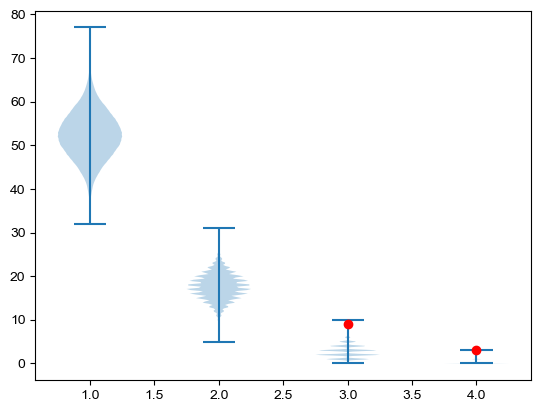

In [72]:
plt.violinplot([dist[x] for x in [1,2,3,4]])
plt.plot([3],[9],'ro')
plt.plot([4],[3],'ro')

In [73]:
len([x for x in dist[4] if x>=3])/100000

0.00023

In [74]:
len([x for x in dist[3] if x>=9])/100000

0.00032

In [75]:
len([x for x in dist[2] if x>=8])/100000

0.99981

## GO enrichment

In [76]:
frequent_hits_list = [x for x in screen_1_counts[is_test&below_ON_T3_threshold].Gene.value_counts().to_dict().keys() if screen_1_counts[is_test&below_ON_T3_threshold].Gene.value_counts().to_dict()[x]>1]
frequent_hits_list

['C4_00560C',
 'C4_01750C',
 'C4_01150W',
 'C1_12610W',
 'CR_04140W',
 'CR_01370C',
 'C1_00510W',
 'C3_01080W',
 'C2_10280C',
 'C2_09380W',
 'C2_07680W',
 'C1_00400W',
 'C3_05800W',
 'CR_07390C',
 'C2_03560C',
 'C7_00730W',
 'C2_05500W',
 'C4_01980C',
 'C1_09960W',
 'C1_05500W']

In [77]:
essential_gene_set = 131
background_set = 6473

component_table = pd.read_excel('./GO_component.xlsx')
component_table['Cluster frequency'] = component_table['Cluster frequency'].str.split(' ').str[0].astype(int)
component_table['Cluster incidence'] = component_table['Cluster frequency']
component_table['Cluster frequency'] = component_table['Cluster incidence']/essential_gene_set

component_table['Background frequency'] = component_table['Background frequency'].str.split(' ').str[0].astype(int)
component_table['Background incidence'] = component_table['Background frequency']
component_table['Background frequency'] = component_table['Background incidence']/background_set

component_table['Enrichment'] = component_table['Cluster frequency']/component_table['Background frequency']

component_table['Gene(s) annotated to the term'] = component_table['Gene(s) annotated to the term'].str.split(':')

frequent_hit_overlap = {}

for GO_term in list(component_table.index):
    gene_list = component_table.loc[GO_term]['Gene(s) annotated to the term']
    frequent_hit_overlap[GO_term] = len([x for x in gene_list if x[:-2] in frequent_hits_list])

component_table['Frequent hit overlap'] = pd.Series(frequent_hit_overlap)

component_table['Frequent hit frequency'] = component_table['Frequent hit overlap']/component_table['Cluster incidence']
component_table['Frequent hit enrichment'] = component_table['Frequent hit frequency']/component_table['Cluster frequency']

component_table = component_table[['GOID', 'GO_term', 'Background incidence','Background frequency',
                                   'Cluster incidence','Cluster frequency','Enrichment', 'Frequent hit overlap', 'Frequent hit frequency', 'Frequent hit enrichment',
                                   'Corrected P-value', 'False discovery rate', 'Gene(s) annotated to the term', 'Directly Annotated GOID List']]

component_table

,GOID,GO_term,Background incidence,Background frequency,Cluster incidence,Cluster frequency,Enrichment,Frequent hit overlap,Frequent hit frequency,Frequent hit enrichment,Corrected P-value,False discovery rate,Gene(s) annotated to the term,Directly Annotated GOID List
0,98798,mitochondrial protein-containing complex,143,0.022092,28,0.213740,9.675119,9,0.321429,1.503827,1.770000e-18,0.0000,"[C1_00450C_A, C1_01600W_A, C1_03280W_A, C1_055...",30061:5763:44284:5789:5840:5762:5886:15934:574...
1,313,organellar ribosome,83,0.012822,20,0.152672,11.906558,8,0.400000,2.620000,1.200000e-14,0.0000,"[C1_01600W_A, C1_03280W_A, C1_05500W_A, C1_079...",5763:5840:5762:15934:15935
2,5761,mitochondrial ribosome,83,0.012822,20,0.152672,11.906558,8,0.400000,2.620000,1.200000e-14,0.0000,"[C1_01600W_A, C1_03280W_A, C1_05500W_A, C1_079...",5763:5840:5762:15934:15935
3,5739,mitochondrion,659,0.101808,46,0.351145,3.449107,13,0.282609,0.804820,9.600000e-13,0.0000,"[C1_00450C_A, C1_00510W_A, C1_01600W_A, C1_026...",140453:5763:9986:5789:42645:31966:5762:5886:15...
4,43231,intracellular membrane-bounded organelle,2623,0.405222,93,0.709924,1.751939,17,0.182796,0.257486,1.400000e-10,0.0000,"[C1_00220W_A, C1_00400W_A, C1_00450C_A, C1_005...",71986:5763:5628:9986:5654:110085:31965:42645:3...
5,43227,membrane-bounded organelle,2672,0.412792,93,0.709924,1.719811,17,0.182796,0.257486,5.030000e-10,0.0000,"[C1_00220W_A, C1_00400W_A, C1_00450C_A, C1_005...",71986:5763:5628:9986:5654:110085:31965:42645:3...
6,43229,intracellular organelle,2943,0.454658,97,0.740458,1.628605,17,0.175258,0.236688,2.620000e-09,0.0000,"[C1_00220W_A, C1_00400W_A, C1_00450C_A, C1_005...",71986:5763:5628:9986:5654:110085:31965:42645:3...
7,5622,intracellular anatomical structure,3277,0.506257,103,0.786260,1.553085,17,0.165049,0.209916,3.300000e-09,0.0000,"[C1_00220W_A, C1_00400W_A, C1_00450C_A, C1_005...",71986:5763:5628:9986:5654:110085:31965:42645:3...
8,44391,ribosomal subunit,162,0.025027,20,0.152672,6.100273,8,0.400000,2.620000,7.380000e-09,0.0000,"[C1_01600W_A, C1_03280W_A, C1_05500W_A, C1_079...",5763:5762:15934:5840:15935
9,43226,organelle,2995,0.462691,97,0.740458,1.600329,17,0.175258,0.236688,8.990000e-09,0.0000,"[C1_00220W_A, C1_00400W_A, C1_00450C_A, C1_005...",71986:5763:5628:9986:5654:110085:31965:42645:3...


In [78]:
component_table[component_table['GO_term']=='mitochondrion']

,GOID,GO_term,Background incidence,Background frequency,Cluster incidence,Cluster frequency,Enrichment,Frequent hit overlap,Frequent hit frequency,Frequent hit enrichment,Corrected P-value,False discovery rate,Gene(s) annotated to the term,Directly Annotated GOID List
3,5739,mitochondrion,659,0.101808,46,0.351145,3.449107,13,0.282609,0.80482,9.600000e-13,0.0,"[C1_00450C_A, C1_00510W_A, C1_01600W_A, C1_026...",140453:5763:9986:5789:42645:31966:5762:5886:15...


In [79]:
np.array([[6473-659, 659],
[131-46,   46]])

array([[5814,  659],
       [  85,   46]])

In [80]:
stats.fisher_exact([[6473-659, 659], # 659 GO: mitochondrion in genome across 6473 genes
                    [131-46,   46]]) # 46 GO: mitochondrion in library across 131 genes

SignificanceResult(statistic=4.7745068285280725, pvalue=4.190130769500943e-14)

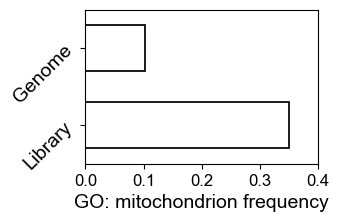

In [81]:
plt.figure(figsize=(3,2))

plt.barh([2,1.5],[0.101808, 0.351145], color='white', edgecolor='k', linewidth=1.25, height=0.3)

plt.yticks([2,1.5], ['Genome', 'Library'], fontsize=14,rotation=45)

plt.xticks(fontsize=12)
plt.xlabel('GO: mitochondrion frequency', fontsize=14)
plt.xlim(0,0.4)
plt.ylim(1.25, 2.25)

plt.savefig('./figures/mito_enrich.svg', dpi=300, format='svg')

In [86]:
screen_1_counts.to_csv('./table_S6.csv')